In [2]:
import pyreadstat
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import flwr as fl
from flwr.simulation import start_simulation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import inspect
import random
import copy


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)



In [4]:
# Data Extraction

path = r"c:\Users\usher\Downloads\NGIR7BDT\NGIR7BFL.DTA"

df, meta = pyreadstat.read_dta(path)

print("Dataset loaded sucessfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded sucessfully
Rows: 41821
Columns: 5394


In [5]:
print("First 30 variables:")
print(df.columns[:30].tolist())

print("\nLast 30 variables:")
print(df.columns[-30:].tolist())

First 30 variables:
['caseid', 'v000', 'v001', 'v002', 'v003', 'v004', 'v005', 'v006', 'v007', 'v008', 'v008a', 'v009', 'v010', 'v011', 'v012', 'v013', 'v014', 'v015', 'v016', 'v017', 'v018', 'v019', 'v019a', 'v020', 'v021', 'v022', 'v023', 'v024', 'v025', 'v026']

Last 30 variables:
['s434ig_1', 's434ig_2', 's434ig_3', 's434ig_4', 's434ig_5', 's434ig_6', 's434ix_1', 's434ix_2', 's434ix_3', 's434ix_4', 's434ix_5', 's434ix_6', 's434iz_1', 's434iz_2', 's434iz_3', 's434iz_4', 's434iz_5', 's434iz_6', 's434k_1', 's434k_2', 's434k_3', 's434k_4', 's434k_5', 's434k_6', 's434l_1', 's434l_2', 's434l_3', 's434l_4', 's434l_5', 's434l_6']


In [6]:
df.head(10)

,caseid,v000,v001,v002,v003,v004,v005,v006,v007,v008,...,s434k_3,s434k_4,s434k_5,s434k_6,s434l_1,s434l_2,s434l_3,s434l_4,s434l_5,s434l_6
0,1 1 2,NG7,1,1,2,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1 6 4,NG7,1,6,4,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1 11 1,NG7,1,11,1,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1 25 2,NG7,1,25,2,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1 30 1,NG7,1,30,1,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1 35 2,NG7,1,35,2,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1 40 3,NG7,1,40,3,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1 40 5,NG7,1,40,5,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1 45 2,NG7,1,45,2,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1 54 1,NG7,1,54,1,1,1335530,9,2018,1425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print(df['v024'].value_counts().sort_index())
print(meta.variable_value_labels.get("v024"))

v024
1     7772
2     7639
3    10129
4     5571
5     5080
6     5630
Name: count, dtype: int64
{1: 'north central', 2: 'north east', 3: 'north west', 4: 'south east', 5: 'south south', 6: 'south west'}


In [8]:
# finding the possible maternal-health variables

keywords = [
    "birth",
    "pregnancy",
    "maternal",
    "antenatal",
    "delivery",
    "health",
    "faculty",
    "skilled",
    "contraceptive"
]

label_matches = []

for col, label in meta.column_names_to_labels.items():
    label_text = str(label).lower()

    if any(keyword in label_text for keyword in keywords):
        label_matches.append((col, label))

print("Number of matching variables:", len(label_matches))

for col, label in label_matches:
    print(f"{col} - {label}")

Number of matching variables: 1283
v009 - respondent's month of birth
v010 - respondent's year of birth
v011 - date of birth (cmc)
bidx_01 - birth column number
bidx_02 - birth column number
bidx_03 - birth column number
bidx_04 - birth column number
bidx_05 - birth column number
bidx_06 - birth column number
bidx_07 - birth column number
bidx_08 - birth column number
bidx_09 - birth column number
bidx_10 - birth column number
bidx_11 - birth column number
bidx_12 - birth column number
bidx_13 - birth column number
bidx_14 - birth column number
bidx_15 - birth column number
bidx_16 - birth column number
bidx_17 - birth column number
bidx_18 - birth column number
bidx_19 - birth column number
bidx_20 - birth column number
bord_01 - birth order number
bord_02 - birth order number
bord_03 - birth order number
bord_04 - birth order number
bord_05 - birth order number
bord_06 - birth order number
bord_07 - birth order number
bord_08 - birth order number
bord_09 - birth order number
bord_10 

In [9]:
# Identifying the exact variables available

candidate_vars = [
    "v024",  # Region
    "v025",  # Urban/rural
    "v012",  # Age
    "v106",  # Education
    "v190",  # Wealth index
    "v714",  # currently working
    "v130",  # Ethnicity
    "v131",  # Religion
    "v151",  # Sex of household head
    "v481",  # Health insurance
]

for var in candidate_vars:
    if var in df.columns:
        print(f"{var} - {meta.column_names_to_labels.get(var)}")
    else:
        print(f"{var} - NOT FOUND")

v024 - region
v025 - type of place of residence
v012 - respondent's current age
v106 - highest educational level
v190 - wealth index combined
v714 - respondent currently working
v130 - religion
v131 - ethnicity
v151 - sex of household head
v481 - covered by health insurance


In [10]:
df[candidate_vars].head()

,v024,v025,v012,v106,v190,v714,v130,v131,v151,v481
0,1,1,40,3,5,1,2,6,1,0
1,1,1,16,2,5,0,2,9,1,0
2,1,1,37,3,5,0,1,9,2,0
3,1,1,27,3,5,1,2,96,1,0
4,1,1,29,2,5,1,2,96,2,0


In [11]:
# checking the quallity of the variables

candidate_vars = [
    "v024", "v025", "v012", "v106", 'v190',
    "v714", "v130", "v131", "v151", "v481"
]

missing = df[candidate_vars].isna().sum()

print("Missing values:", missing)

print("\nMissing percentage:")
print((missing / len(df) * 100).round(2))

Missing values: v024    0
v025    0
v012    0
v106    0
v190    0
v714    0
v130    0
v131    0
v151    0
v481    0
dtype: int64

Missing percentage:
v024    0.0
v025    0.0
v012    0.0
v106    0.0
v190    0.0
v714    0.0
v130    0.0
v131    0.0
v151    0.0
v481    0.0
dtype: float64


In [12]:
# Understanding the value labels for these variables

for var in candidate_vars:
    print(f"\n{'='*50}")
    print(f"{var} - {meta.column_names_to_labels.get(var)}")
    print(meta.variable_value_labels.get(var, "No value labels"))


v024 - region
{1: 'north central', 2: 'north east', 3: 'north west', 4: 'south east', 5: 'south south', 6: 'south west'}

v025 - type of place of residence
{1: 'urban', 2: 'rural'}

v012 - respondent's current age
No value labels

v106 - highest educational level
{0: 'no education', 1: 'primary', 2: 'secondary', 3: 'higher'}

v190 - wealth index combined
{1: 'poorest', 2: 'poorer', 3: 'middle', 4: 'richer', 5: 'richest'}

v714 - respondent currently working
{0: 'no', 1: 'yes'}

v130 - religion
{1: 'catholic', 2: 'other christian', 3: 'islam', 4: 'traditionalist', 96: 'other'}

v131 - ethnicity
{1: 'ekoi', 2: 'fulani', 3: 'hausa', 4: 'ibibio', 5: 'igala', 6: 'igbo', 7: 'ijaw/izon', 8: 'kanuri/beriberi', 9: 'tiv', 10: 'yoruba', 96: 'other', 98: "don't know"}

v151 - sex of household head
{1: 'male', 2: 'female'}

v481 - covered by health insurance
{0: 'no', 1: 'yes'}


In [13]:
# investigating the actual maternal-health outcomes

outcome_candidates = [
    "m15_1",  # Place of delivery
    "m14_1",  # number of antenatal visits
    "m13_1",  # timing of first antenatal visit
    "m17_1",  # Caesarean section
]

for var in outcome_candidates:
    print("\n" + "="*50)
    print(f"{var} - {meta.column_names_to_labels.get(var)}")
    print("Values Labels:")
    print(meta.variable_value_labels.get(var, "No value labels"))

    print("\nValue counts:")
    print(df[var].value_counts(dropna=False).sort_index())


m15_1 - place of delivery
Values Labels:
{10: 'home', 11: "respondent's home", 12: 'other home', 20: 'public sector', 21: 'government hospital', 22: 'government health center', 23: 'government health post', 26: 'other public sector', 30: 'private sector', 31: 'private hospital/clinic', 36: 'other private sector', 96: 'other'}

Value counts:
m15_1
11     11267
12      1174
21      2972
22      3081
23       243
26        13
31      2647
36        45
96       350
NaN    20029
Name: count, dtype: int64

m14_1 - number of antenatal visits during pregnancy
Values Labels:
{0: 'no antenatal visits', 98: "don't know"}

Value counts:
m14_1
0       5365
1        583
2        968
3       2242
4       2716
5       2344
6       2095
7       1055
8       1079
9        443
10       806
11       160
12       472
13        80
14       113
15       231
16       166
17        56
18       115
19        33
20       343
98       327
NaN    20029
Name: count, dtype: int64

m13_1 - timing of 1st antenatal ch

In [14]:
## Creating a temporary binary version of m15_1 (place of delivery)
# Create a temporary binary facility-delivery outcome
# 0 = home delivery
# 1 = facility delivery

facility_delivery = df["m15_1"].map(
    lambda x: 0 if x in [10, 11, 12]
    else 1 if x in [20, 21, 22, 23, 24, 26, 30, 31, 36]
    else None
)

print("Overall outcome distribution:")
print(facility_delivery.value_counts(dropna=False))

Overall outcome distribution:
m15_1
NaN    20379
0.0    12441
1.0     9001
Name: count, dtype: int64


In [15]:
print("\nFacility delivery by region:")

regional_table = pd.crosstab(
    df["v024"],
    facility_delivery,
    normalize="index"
) * 100

regional_table.index = [
    "North Central",
    "North East",
    "North West",
    "South East",
    "South South",
    "South West"
]

regional_table.columns = ["Home//Non-Facility (%)", "Facility (%)"]

print(regional_table.round(2))


Facility delivery by region:
               Home//Non-Facility (%)  Facility (%)
North Central                   47.97         52.03
North East                      74.01         25.99
North West                      84.32         15.68
South East                      19.29         80.71
South South                     51.32         48.68
South West                      18.66         81.34


In [16]:
df = df.dropna(subset=["m15_1"])

In [17]:
print("Births in last 5 years:")
print(df["v208"].value_counts(dropna=False).sort_index())

Births in last 5 years:
v208
1    11363
2     8852
3     1461
4      108
5        6
6        2
Name: count, dtype: int64


In [18]:
print("m15_1 by v208:")
print(
    pd.crosstab(
        df["v208"],
        df["m15_1"],
        dropna=False
    )
)

m15_1 by v208:
m15_1    11   12    21    22   23  26    31  36   96
v208                                                
1      5255  679  1775  1751  142   7  1524  22  208
2      5145  413  1022  1118   82   6   923  19  124
3       806   76   160   198   17   0   183   4   17
4        58    5    12    13    2   0    17   0    1
5         3    1     2     0    0   0     0   0    0
6         0    0     1     1    0   0     0   0    0


In [19]:
## Feature Selection

feature_candidates = [
    "v012",   # Age
    "v025",   # Urban/rural
    "v106",   # Education
    "v190",   # Wealth index
    "v714",   # Currently working
    "v151",   # Sex of household head
    "v481",   # Health insurance
    "v208"    # Number of births in last 5 years
]

for var in feature_candidates:
    print("\n" + "=" * 60)
    print(f"{var} → {meta.column_names_to_labels.get(var)}")
    
    print("\nValue counts:")
    print(df[var].value_counts(dropna=False).sort_index())


v012 → respondent's current age

Value counts:
v012
15      17
16      69
17     245
18     453
19     409
20    1163
21     586
22     931
23     807
24     719
25    1868
26     911
27     995
28    1099
29     744
30    1817
31     645
32     906
33     698
34     604
35    1405
36     613
37     533
38     671
39     400
40     799
41     287
42     337
43     216
44     135
45     349
46     114
47     100
48      96
49      51
Name: count, dtype: int64

v025 → type of place of residence

Value counts:
v025
1     7710
2    14082
Name: count, dtype: int64

v106 → highest educational level

Value counts:
v106
0    9527
1    3410
2    7064
3    1791
Name: count, dtype: int64

v190 → wealth index combined

Value counts:
v190
1    5025
2    4905
3    4586
4    4025
5    3251
Name: count, dtype: int64

v714 → respondent currently working

Value counts:
v714
0     6977
1    14815
Name: count, dtype: int64

v151 → sex of household head

Value counts:
v151
1    19512
2     2280
Name: coun

In [20]:
# First Baseline feature set

baseline_features = [
    "v012",  # Age
    "v025",  # Urban/rural residence
    "v016",  # Education
    "v190",  # Wealth index
    "v714",  # Currently working
]

client_variable = "v024"

target_variable = "m15_1"

In [21]:
# Creating a temporary modelling subset

temp_df = df[df["m15_1"].notna()].copy()

print("Total eligible observations:", len(temp_df))

print("\nObservations per region:")
print(temp_df["v024"].value_counts().sort_index())

print("\nHome vs Facility delivery per region:")

print(
    pd.crosstab(
        temp_df["v024"],
        facility_delivery[temp_df.index]
    )
)

Total eligible observations: 21792

Observations per region:
v024
1    3875
2    4506
3    6309
4    2365
5    2174
6    2563
Name: count, dtype: int64

Home vs Facility delivery per region:
m15_1   0.0   1.0
v024             
1      1841  1997
2      3329  1169
3      5318   989
4       451  1887
5      1052   998
6       450  1961


In [22]:
# Checking whether code 96 explains the discrepancy

print("Records with m15_1 = 96 by region:\n")

print(
    temp_df[temp_df["m15_1"] == 96]
    .groupby("v024")
    .size()
)

print("\nTotal records coded as 96:")
print((temp_df["m15_1"] == 96).sum())

Records with m15_1 = 96 by region:

v024
1     37
2      8
3      2
4     27
5    124
6    152
dtype: int64

Total records coded as 96:
350


In [23]:
# Creating a clean binary facility-delivery target

home_codes = [11, 12]

facility_codes = [21, 22, 23, 26, 31, 36]

# Starting with the eligible population
model_df = df[df["m15_1"].notna()].copy()

# Creating the binary target
model_df["facility_delivery"] = model_df["m15_1"].map(
    lambda x: 0 if x in home_codes
    else 1 if x in facility_codes
    else None
)

# removing observations that cannot be clearly classified
model_df = model_df.dropna(subset=["facility_delivery"]).copy()

# Converting target to integer
model_df["facility_delivery"] = model_df["facility_delivery"].astype(int)

print("Final modelling observations:", len(model_df))

print("\nTarget distribution:")
print(model_df["facility_delivery"].value_counts())

print("\nTarget Percentage:")
print(
    model_df["facility_delivery"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
      


Final modelling observations: 21442

Target distribution:
facility_delivery
0    12441
1     9001
Name: count, dtype: int64

Target Percentage:
facility_delivery
0    58.02
1    41.98
Name: proportion, dtype: float64


In [24]:
# Validating the final dataset across our  six clients

# Number of observation per federated client

print("Observations per region:")
print(model_df["v024"].value_counts().sort_index())


# Home vs Facility delivery by region

print("\nHome vs Facility delivery by region:")

regional_distribution = pd.crosstab(
    model_df["v024"],
    model_df["facility_delivery"]
)

print(regional_distribution)


# Percentage distribution of region

print("\nPercentage distribution by region:")

regional_percentage = (
    pd.crosstab(
        model_df["v024"],
        model_df["facility_delivery"],
        normalize="index"
    )
    * 100
).round(2)

print(regional_percentage)


Observations per region:
v024
1    3838
2    4498
3    6307
4    2338
5    2050
6    2411
Name: count, dtype: int64

Home vs Facility delivery by region:
facility_delivery     0     1
v024                         
1                  1841  1997
2                  3329  1169
3                  5318   989
4                   451  1887
5                  1052   998
6                   450  1961

Percentage distribution by region:
facility_delivery      0      1
v024                           
1                  47.97  52.03
2                  74.01  25.99
3                  84.32  15.68
4                  19.29  80.71
5                  51.32  48.68
6                  18.66  81.34


In [25]:
# Defining the variables needed for our first experiment

features = [
    "v012",  # Age
    "v025",  # Urban/rural residence
    "v106",  # Education level
    "v190",  # Wealth index
    "v714",  # Currently working
]

client_column = "v024"
target_column = "facility_delivery"

# Creating the clean project Dataset

project_df = model_df[
    features + [client_column, target_column]
].copy()

# Check the result

print("Project dataset shape:", project_df.shape)

print("\nCloumns:")
print(project_df.columns.tolist())

Project dataset shape: (21442, 7)

Cloumns:
['v012', 'v025', 'v106', 'v190', 'v714', 'v024', 'facility_delivery']


In [26]:
print("Data types:")
print(project_df.dtypes)

print("\n" + "=" * 50)

print("Missing values:")
print(project_df.isnull().sum())

print("\n" + "=" * 50)

print("Unique values per column:")
print(project_df.nunique())

Data types:
v012                 int64
v025                 int64
v106                 int64
v190                 int64
v714                 int64
v024                 int64
facility_delivery    int64
dtype: object

Missing values:
v012                 0
v025                 0
v106                 0
v190                 0
v714                 0
v024                 0
facility_delivery    0
dtype: int64

Unique values per column:
v012                 35
v025                  2
v106                  4
v190                  5
v714                  2
v024                  6
facility_delivery     2
dtype: int64


In [27]:
categorical_features = [
    "v025",
    "v106",
    "v190",
    "v714"
]

for feature in categorical_features:
    
    print("\n" + "=" * 70)
    print(f"{feature} distribution by region")
    print("=" * 70)
    
    distribution = pd.crosstab(
        project_df["v024"],
        project_df[feature],
        normalize="index"
    ) * 100
    
    print(distribution.round(2))


v025 distribution by region
v025      1      2
v024              
1     30.88  69.12
2     20.21  79.79
3     24.29  75.71
4     65.14  34.86
5     34.59  65.41
6     69.35  30.65

v106 distribution by region
v106      0      1      2      3
v024                            
1     35.96  19.70  34.24  10.11
2     66.72  13.61  16.45   3.22
3     74.12  11.29  11.70   2.89
4      3.34  20.27  63.13  13.26
5      6.00  17.76  63.37  12.88
6     10.12  16.84  53.21  19.83

v190 distribution by region
v190      1      2      3      4      5
v024                                   
1     16.52  24.02  24.99  20.11  14.36
2     40.57  27.68  17.99  10.47   3.29
3     35.17  30.73  18.15   9.96   5.99
4      5.35  10.82  26.69  33.32  23.82
5      3.61  14.15  26.29  28.15  27.80
6      5.02   9.00  17.30  28.91  39.78

v714 distribution by region
v714      0      1
v024              
1     29.05  70.95
2     38.24  61.76
3     46.55  53.45
4     18.82  81.18
5     21.41  78.59
6     11.07  88

In [28]:
## Completing Feature Distribution

# Age distribution summary by region

age_summary = project_df.groupby("v024")["v012"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

print(age_summary)

region_names = {
    1: "North Central",
    2: "North East",
    3: "North West",
    4: "South East",
    5: "South South",
    6: "South West"
}

age_summary_named = age_summary.copy()
age_summary_named.index = age_summary_named.index.map(region_names)

print(age_summary_named)

      count   mean  median   std  min  max
v024                                      
1      3838  29.46    29.0  6.87   15   49
2      4498  28.91    28.0  7.44   15   49
3      6307  29.17    28.0  7.56   15   49
4      2338  31.29    31.0  6.75   15   49
5      2050  30.32    30.0  6.83   15   49
6      2411  31.04    31.0  6.55   15   49
               count   mean  median   std  min  max
v024                                               
North Central   3838  29.46    29.0  6.87   15   49
North East      4498  28.91    28.0  7.44   15   49
North West      6307  29.17    28.0  7.56   15   49
South East      2338  31.29    31.0  6.75   15   49
South South     2050  30.32    30.0  6.83   15   49
South West      2411  31.04    31.0  6.55   15   49


In [29]:
# Create a dictionary containing the data for each region

region_names = {
    1: "North Central",
    2: "North East",
    3: "North West",
    4: "South East",
    5: "South South",
    6: "South West"
}

client_data = {}

for region_code, region_name in region_names.items():

    client_df = project_df[
        project_df["v024"] == region_code
    ].copy()

    client_data[region_name] = client_df

    print(
        f"{region_name}: {client_df.shape[0]} observations"
    )

North Central: 3838 observations
North East: 4498 observations
North West: 6307 observations
South East: 2338 observations
South South: 2050 observations
South West: 2411 observations


In [30]:
## Spliting Each Client into Training and Test Data

# Define the feature columns and target

features = [
    "v012",  # Age
    "v025",  # Residence
    "v106",  # Education
    "v190",  # Wealth
    "v714"   # Employment
]

target = "facility_delivery"


# Dictionary to store train/test data for each client

client_splits = {}


for region_name, client_df in client_data.items():

    # Separate features and target
    X = client_df[features].copy()
    y = client_df[target].copy()

    # Split the client's data
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # Store the split
    client_splits[region_name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print(f"\n{region_name}")

    print(f"Training samples: {len(X_train)}")
    print(f"Testing samples:  {len(X_test)}")

    print("\nTraining target distribution:")
    print(y_train.value_counts(normalize=True).round(4))

    print("\nTesting target distribution:")
    print(y_test.value_counts(normalize=True).round(4))


North Central
Training samples: 3070
Testing samples:  768

Training target distribution:
facility_delivery
1    0.5202
0    0.4798
Name: proportion, dtype: float64

Testing target distribution:
facility_delivery
1    0.5208
0    0.4792
Name: proportion, dtype: float64

North East
Training samples: 3598
Testing samples:  900

Training target distribution:
facility_delivery
0    0.7401
1    0.2599
Name: proportion, dtype: float64

Testing target distribution:
facility_delivery
0    0.74
1    0.26
Name: proportion, dtype: float64

North West
Training samples: 5045
Testing samples:  1262

Training target distribution:
facility_delivery
0    0.8432
1    0.1568
Name: proportion, dtype: float64

Testing target distribution:
facility_delivery
0    0.8431
1    0.1569
Name: proportion, dtype: float64

South East
Training samples: 1870
Testing samples:  468

Training target distribution:
facility_delivery
1    0.807
0    0.193
Name: proportion, dtype: float64

Testing target distribution:
facil

In [31]:
# Combine ONLY the training data from all clients
# This will be used ONLY to fit preprocessing parameters

combined_X_train = pd.concat(
    [
        client_splits[region]["X_train"]
        for region in client_splits
    ],
    axis=0
)

print("Combined training shape:", combined_X_train.shape)

print("\nFirst 5 rows:")
display(combined_X_train.head())

Combined training shape: (17151, 5)

First 5 rows:


,v012,v025,v106,v190,v714
4230,31,2,3,5,1
930,22,2,1,3,1
2534,38,1,2,4,1
6357,27,2,0,2,1
503,25,2,2,3,1


In [32]:
# Create the scaler

age_scaler = StandardScaler()

# Fit the scaler using ONLY the combined training data

age_scaler.fit(combined_X_train[["v012"]])

# Show the learned parameters

print("Training age mean:", age_scaler.mean_[0])
print("Training age standard deviation:", age_scaler.scale_[0])

Training age mean: 29.715235263249955
Training age standard deviation: 7.159848955150018


In [33]:
## Creating our preprocessing Function
"""
1. Standardize age
2. Converting residence to binary
3. Keeping the other varibales numerical
"""

def preprocess_features(X, scaler):
    
    # Create a copy so we don't modify the original data
    X_processed = X.copy()
    
    # Standardize age
    X_processed["v012"] = scaler.transform(
        X_processed[["v012"]]
    ).flatten()
    
    # Convert residence
    # 1 = Urban
    # 2 = Rural
    
    X_processed["v025"] = X_processed["v025"].map({
        1: 1,
        2: 0
    })
    
    return X_processed

In [34]:
## Tesinkg the function on one client

# Getting Northing Central data

X_nc_train = client_splits["North Central"]["X_train"]

# Preprocess it
X_nc_train_processed = preprocess_features(
    X_nc_train,
    age_scaler
)

# Display the first 5 rows
display(X_nc_train_processed.head())

,v012,v025,v106,v190,v714
4230,0.179440,0,3,5,1
930,-1.077570,0,1,3,1
2534,1.157114,1,2,4,1
6357,-0.379231,0,0,2,1
503,-0.658566,0,2,3,1


In [35]:
print("Mean of scaled age:")
print(X_nc_train_processed["v012"].mean())

print("\nStandard deviation of scaled age:")
print(X_nc_train_processed["v012"].std())

Mean of scaled age:
-0.0444831440209495

Standard deviation of scaled age:
0.9509185548324696


In [36]:
## Process all six Regional clients

for region in client_splits:
    
    # Process training features
    client_splits[region]["X_train_processed"] = preprocess_features(
        client_splits[region]["X_train"],
        age_scaler
    )
    
    # Process testing features
    client_splits[region]["X_test_processed"] = preprocess_features(
        client_splits[region]["X_test"],
        age_scaler
    )

print("Preprocessing completed for all six regional clients.")

# verification

for region in client_splits:
    
    X_train = client_splits[region]["X_train_processed"]
    X_test = client_splits[region]["X_test_processed"]
    
    print(f"\n{region}")
    print(f"Training shape: {X_train.shape}")
    print(f"Testing shape: {X_test.shape}")
    print(f"Missing values: {X_train.isnull().sum().sum()}")


Preprocessing completed for all six regional clients.

North Central
Training shape: (3070, 5)
Testing shape: (768, 5)
Missing values: 0

North East
Training shape: (3598, 5)
Testing shape: (900, 5)
Missing values: 0

North West
Training shape: (5045, 5)
Testing shape: (1262, 5)
Missing values: 0

South East
Training shape: (1870, 5)
Testing shape: (468, 5)
Missing values: 0

South South
Training shape: (1640, 5)
Testing shape: (410, 5)
Missing values: 0

South West
Training shape: (1928, 5)
Testing shape: (483, 5)
Missing values: 0


In [37]:

# Combine processed training data from all regions
X_central_train = pd.concat(
    [
        client_splits[region]["X_train_processed"]
        for region in client_splits
    ],
    axis=0
)

# Combine training targets
y_central_train = pd.concat(
    [
        client_splits[region]["y_train"]
        for region in client_splits
    ],
    axis=0
)

print("Centralized training shape:", X_central_train.shape)
print("Centralized target shape:", y_central_train.shape)

print("\nTarget distribution:")
print(y_central_train.value_counts(normalize=True))

Centralized training shape: (17151, 5)
Centralized target shape: (17151,)

Target distribution:
facility_delivery
0    0.580316
1    0.419684
Name: proportion, dtype: float64


In [38]:
## Builing the Neural Network

# Creating our neural network

class FacilityDeliveryModel(nn.Module):

    def __init__(self):
        super(FacilityDeliveryModel, self).__init__()

        self.network = nn.Sequential(

            # Input layer: 5 features
            nn.Linear(5, 16),
            nn.ReLU(),

            # Hidden layer
            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)
    
# Creating the Model

model = FacilityDeliveryModel()

print(model)


FacilityDeliveryModel(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [39]:
# Building the local trnaining and evaluation functions

# Feature columns used by the model
feature_columns = [
    "v012",
    "v025",
    "v106",
    "v190",
    "v714"
]

# Converting centralized training data to Pytorch tensors

X_train_tensor = torch.tensor(
    X_central_train[feature_columns].values,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_central_train.values,
    dtype=torch.float32
).view(-1, 1)

print("Training features shape:", X_train_tensor.shape)
print("Training labels shape:", y_train_tensor.shape)

Training features shape: torch.Size([17151, 5])
Training labels shape: torch.Size([17151, 1])


In [40]:
# Defining the loss function and Optimizer

criterion = nn.BCEWithLogitsLoss()

# Defining the optimizer

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [41]:
outputs = model(X_train_tensor)

print("Output shape:", outputs.shape)
print("\nFirst 5 raw outputs:")
print(outputs[:5])

Output shape: torch.Size([17151, 1])

First 5 raw outputs:
tensor([[-0.1270],
        [-0.1094],
        [-0.1180],
        [-0.1213],
        [-0.1061]], grad_fn=<SliceBackward0>)


In [42]:
# calculate the loss

loss = criterion(outputs, y_train_tensor)

print("Initial loss:", loss.item())

Initial loss: 0.6844825744628906


In [43]:
## Backpropagation: where the learning actually happens

# Clear any previous gradients
optimizer.zero_grad()

# Calculate gradients
loss.backward()

# Update the model's weights
optimizer.step()

print("One training step completed successfully!")

One training step completed successfully!


In [44]:
## Verifying if the model improved

# Making predictions again after the weight update

outputs_after = model(X_train_tensor)

# Calculating the new loss
loss_after = criterion(outputs_after, y_train_tensor)

print("Loss before update:", loss.item())
print("Loss after update:", loss_after.item() )


Loss before update: 0.6844825744628906
Loss after update: 0.6840206980705261


The loss decreased because backpropagation calculated how the model's weights contributed to the error, and Adam used those gradients to adjust the weights toward a lower loss.


I am stopping here im centralised training because it is only to verify that I understand and have a functioning PyTorch model.

In [45]:
## Building the local training loop

# Creating a PyTorch Dataset

class FacilityDeliveryDataset(Dataset): # Dataset is PyTorch way of representing training data
    def __init__(self, X, y):
        self.X = torch.tensor(
            X.values,
            dtype=torch.float32
        ) 

        self.y = torch.tensor(
            y.values,
            dtype=torch.float32
        ).view(-1, 1)  # converts the facility-delivery target into the shape our model expects

    def __len__(self):
        return len(self.X)  # counts the training examples

    def __getitem__(self, index):
        return self.X[index], self.y[index]  # gives the feature and target for each example index

In [46]:
# Testing one Client (North Central) first

nc_dataset = FacilityDeliveryDataset(
    client_splits["North Central"]["X_train_processed"],
    client_splits["North Central"]["y_train"]
)

print("Number od samples:", len(nc_dataset))
print("First sample")
print(nc_dataset[0])

Number od samples: 3070
First sample
(tensor([0.1794, 0.0000, 3.0000, 5.0000, 1.0000]), tensor([1.]))


In [47]:
# creating the dataloader

nc_loader = DataLoader(
    nc_dataset,
    batch_size=32,
    shuffle=True
)

print("Number of batches:", len(nc_loader))

Number of batches: 96


In [48]:
# Writing the local training function

def train_local(model, X_train, y_train, epochs=1, batch_size=32):

    dataset = FacilityDeliveryDataset(
        X_train,
        y_train
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model.train()

    for epoch in range(epochs):

        total_loss = 0.0

        for X_batch, y_batch in loader:

            optimizer.zero_grad()  # clear gradients from previous batch

            outputs = model(X_batch)  # forward pass

            loss = criterion(
                outputs,
                y_batch
            )  # shows how wrong the predictions are

            loss.backward()  # perfoms backpropagation and calculates the gradients

            optimizer.step()  # using the gradients to updates the model's weights

            total_loss += loss.item()

        average_loss = total_loss / len(loader)

        print(
                f"Epoch {epoch + 1}/{epochs}, "
                f"Loss: {average_loss:.4f}"
        )

In [49]:
nc_model = FacilityDeliveryModel()

print("Model created successfully.")

Model created successfully.


In [50]:
print("Starting local training...")

train_local(
    nc_model,
    client_splits["North Central"]["X_train_processed"],
    client_splits["North Central"]["y_train"],
    epochs=1
)

print("Training finished.")

Starting local training...
Epoch 1/1, Loss: 0.6942
Training finished.


## FedAvg prototyping section

In [51]:
## Understanding FedAvg manually first before applying Flower

# Creating a common starting model

global_model = FacilityDeliveryModel()

print(
    "Initial weight:", global_model.network[0].weight[0][0].item()
)

# Giving each client a copy

nc_model = copy.deepcopy(global_model)
ne_model = copy.deepcopy(global_model)

# Training each client locally

train_local(
    nc_model,
    client_splits["North Central"]["X_train_processed"],
    client_splits["North Central"]["y_train"],
    epochs=1
    )

train_local(
    ne_model,
    client_splits["North East"]["X_train_processed"],
    client_splits["North East"]["y_train"],
    epochs=1
    )

# Comparing the trained weights

print("Global model weights:", global_model.network[0].weight[0][0].item())
print("North Central weights:", nc_model.network[0].weight[0][0].item())
print("North East weights:", ne_model.network[0].weight[0][0].item())

Initial weight: -0.03853073716163635
Epoch 1/1, Loss: 0.6676
Epoch 1/1, Loss: 0.6361
Global model weights: -0.03853073716163635
North Central weights: -0.023940574377775192
North East weights: -0.024371568113565445


In [52]:
# Manually calculating FedAvg

nc_weight = nc_model.network[0].weight[0][0].item()
ne_weight = ne_model.network[0].weight[0][0].item()

nc_samples = 3070
ne_samples = 3598

fedavg_weight = (
    (nc_samples / (nc_samples + ne_samples)) * nc_weight
    +
    (ne_samples / (nc_samples + ne_samples)) * ne_weight
)

print("North Central contribution:",
      nc_samples / (nc_samples + ne_samples))

print("North East contribution:",
      ne_samples / (nc_samples + ne_samples))

print("FedAvg weight:",
      fedavg_weight)

North Central contribution: 0.46040791841631673
North East contribution: 0.5395920815836832
FedAvg weight: -0.024173135184819783


In [53]:
## Buidling for six-client FedAvg function

# Creating the FedAvg function

def fedavg(models, sample_counts):

    total_samples = sum(sample_counts)

    global_state = copy.deepcopy(
        models[0].state_dict()
    )

    for key in global_state:

        global_state[key] = sum(
            (sample_counts[i] / total_samples)
            * models[i].state_dict()[key]
            for i in range(len(models))
        )

    return global_state

In [54]:
# Testing it with the two models we already trained

fedavg_state = fedavg(
    [nc_model, ne_model],
    [3070, 3598]
)

print(
    "FedAvg weight:",
    fedavg_state["network.0.weight"][0][0].item()
)

FedAvg weight: -0.024173134937882423


## Actual Federated Learning Experiment

The following section begins the actual six-client federated learning
experiment using Nigeria's six geopolitical zones.

Each client starts from the same global model and trains only on its
local regional training data. The server aggregates client model
parameters using FedAvg.

In [113]:
# Fresh global model for the actual experiment

global_experiment = FacilityDeliveryModel()

print(global_model)

FacilityDeliveryModel(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [114]:
# Creating six identical client models

client_models = {}

for region in region_names.values():
    client_models[region] = copy.deepcopy(global_model)

print("Number of Clients:", len(client_models))

# Verifying that they really are identical

for region, client_model in client_models.items():

    weight = client_model.network[0].weight[0][0].item()

    print(
        region,
        "-",
        weight
    )


Number of Clients: 6
North Central - -0.030768103897571564
North East - -0.030768103897571564
North West - -0.030768103897571564
South East - -0.030768103897571564
South South - -0.030768103897571564
South West - -0.030768103897571564


In [115]:
# Training each of the six clients locally

for region_code, region in region_names.items():

    print(f"\nTraining {region}...")

    train_local(
        client_models[region],
        client_splits[region]["X_train_processed"],
        client_splits[region]["y_train"],
        epochs=1,
        batch_size=32

    )


Training North Central...
Epoch 1/1, Loss: 0.6398

Training North East...
Epoch 1/1, Loss: 0.5771

Training North West...
Epoch 1/1, Loss: 0.4901

Training South East...
Epoch 1/1, Loss: 0.5824

Training South South...
Epoch 1/1, Loss: 0.6725

Training South West...
Epoch 1/1, Loss: 0.5768


In [116]:
# actual fedAvg aggregation

sample_counts = [
    3070,
    3598,
    5045,
    1870,
    1640,
    1928
]

models = [
    client_models["North Central"],
    client_models["North East"],
    client_models["North West"],
    client_models["South East"],
    client_models["South South"],
    client_models["South West"]
]

new_global_state = fedavg(
    models,
    sample_counts
)

print(
    "Aggregated weight:",
    new_global_state["network.0.weight"][0][0].item()
)

Aggregated weight: -0.020766347646713257


In [117]:
# Updating the gloval model

global_model.load_state_dict(new_global_state)

print("Updated global model weight:", global_model.network[0].weight[0][0].item())

Updated global model weight: -0.020766347646713257


In [118]:
def evaluate_model(model, X_test, y_test):

    dataset = FacilityDeliveryDataset(
        X_test,
        y_test
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            outputs = model(X_batch)

            probabilities = torch.sigmoid(outputs)

            predictions = (
                probabilities >= 0.5
            ).float()

            all_predictions.extend(
                predictions.cpu().numpy().flatten()
            )

            all_targets.extend(
                y_batch.cpu().numpy().flatten()
            )

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    precision = precision_score(
        all_targets,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_targets,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_targets,
        all_predictions,
        zero_division=0
    )

    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "macro_f1": macro_f1
    }

In [119]:
# Testing global model on North Central 

nc_metrics = evaluate_model(
    global_model,
    client_splits["North Central"]["X_test_processed"],
    client_splits["North Central"]["y_test"]
)

print(nc_metrics)

{'accuracy': 0.6432291666666666, 'precision': 0.7386363636363636, 'recall': 0.4875, 'f1': 0.5873493975903614, 'macro_f1': 0.6365646070520614}


In [120]:
print("Predicted class distribution")

# Recreating the test dataset
nc_dataset = FacilityDeliveryDataset(
    client_splits["North Central"]['X_test_processed'],
    client_splits["North Central"]["y_test"]
)

nc_loader = DataLoader(
    nc_dataset,
    batch_size=32,
    shuffle=False
)

global_model.eval()

all_predictions = []

with torch.no_grad():

    for X_batch, y_batch in nc_loader:

        outputs = global_model(X_batch)

        probabilities = torch.sigmoid(outputs)

        predictions = (
            probabilities >= 0.5
        ).float()

        all_predictions.extend(
            predictions.cpu().numpy().flatten()
        )

print(
    "Class 0:",
    all_predictions.count(0.0)
)

print(
    "Class 1:",
    all_predictions.count(1.0)
)

Predicted class distribution
Class 0: 504
Class 1: 264


In [121]:
# Evaluating all six regions

round1_results = {}

for region in region_names.values():

    metrics = evaluate_model(
        global_model,
        client_splits[region]["X_test_processed"],
        client_splits[region]["y_test"]

    )

    round1_results[region] = metrics

    print(f"\n{region}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1: {metrics['f1']:.4f}")
    print(f"Macro F1: {metrics['macro_f1']:.4f}")


North Central
Accuracy: 0.6432
Precision: 0.7386
Recall: 0.4875
F1: 0.5873
Macro F1: 0.6366

North East
Accuracy: 0.7700
Precision: 0.6216
Recall: 0.2949
F1: 0.4000
Macro F1: 0.6289

North West
Accuracy: 0.8550
Precision: 0.5460
Recall: 0.4495
F1: 0.4931
Macro F1: 0.7042

South East
Accuracy: 0.7479
Precision: 0.8988
Recall: 0.7751
F1: 0.8324
Macro F1: 0.6619

South South
Accuracy: 0.6366
Precision: 0.5927
Recall: 0.8150
F1: 0.6863
Macro F1: 0.6272

South West
Accuracy: 0.6770
Precision: 0.8810
Recall: 0.6972
F1: 0.7784
Macro F1: 0.5915


### Round 1 observation

After one local training epoch and one FedAvg aggregation, the global
model showed substantial variation in performance across geopolitical
zones. Accuracy ranged from 18.84% in South West to 84.31% in North West,
while positive-class F1 was near zero across all regions.

This early-round result should not be interpreted as final model
performance. The strong regional variation is consistent with the
substantial differences in regional target distributions and motivates
evaluation across multiple federated rounds using metrics beyond
accuracy.

## Multi-Round FedAvg Experiment

In [122]:
def run_fedavg_experiment(
    initial_model,
    client_splits,
    region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32,
    seed=42
):
    set_seed(seed)

    global_model = copy.deepcopy(initial_model)

    results = []

    for round_number in range(1, num_rounds + 1):

        print(f"\n{'=' * 50}")
        print(f"Federated Round {round_number}")
        print(f"{'=' * 50}")

        # Create a dictionary for the six client models
        client_models = {}

        sample_counts = []

        # Give every client a fresh copy of the current global model
        for region_code, region in region_names.items():

            client_models[region] = copy.deepcopy(
                global_model
            )

        # Train each client locally
        for region_code, region in region_names.items():

            print(f"\nTraining {region}...")

            train_local(
                client_models[region],
                client_splits[region]["X_train_processed"],
                client_splits[region]["y_train"],
                epochs=local_epochs,
                batch_size=batch_size
            )

            sample_counts.append(
                len(client_splits[region]["y_train"])
            )

        # Collect the six trained models
        models = [
            client_models[region]
            for region in region_names.values()
        ]

        # Perform FedAvg
        new_global_state = fedavg(
            models,
            sample_counts
        )

        # Update the global model
        global_model.load_state_dict(
            new_global_state
        )

        # Evaluate the new global model
        for region_code, region in region_names.items():

            metrics = evaluate_model(
                global_model,
                client_splits[region]["X_test_processed"],
                client_splits[region]["y_test"]
            )

            results.append({
                "round": round_number,
                "region": region,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "macro_f1": metrics["macro_f1"]
            })

            print(
                f"{region} | "
                f"Accuracy: {metrics['accuracy']:.4f} | "
                f"Macro F1: {metrics['macro_f1']:.4f}"
            )

    return global_model, results

In [123]:
#Creating a completely fresh model

experiment_initial_model = FacilityDeliveryModel()

print(
    "Experiment starting model weight:", 
    experiment_initial_model.network[0].weight[0][0].item()
)

Experiment starting model weight: 0.054682910442352295


In [124]:
fedavg_global_model, fedavg_results = run_fedavg_experiment(
    initial_model=experiment_initial_model,
    client_splits=client_splits,
    region_names=region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32
)


Federated Round 1

Training North Central...
Epoch 1/1, Loss: 0.6727

Training North East...
Epoch 1/1, Loss: 0.6404

Training North West...
Epoch 1/1, Loss: 0.5768

Training South East...
Epoch 1/1, Loss: 0.5914

Training South South...
Epoch 1/1, Loss: 0.6860

Training South West...
Epoch 1/1, Loss: 0.6030
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North East | Accuracy: 0.7400 | Macro F1: 0.4253
North West | Accuracy: 0.8431 | Macro F1: 0.4574
South East | Accuracy: 0.1923 | Macro F1: 0.1613
South South | Accuracy: 0.5122 | Macro F1: 0.3387
South West | Accuracy: 0.1863 | Macro F1: 0.1571

Federated Round 2

Training North Central...
Epoch 1/1, Loss: 0.6677

Training North East...
Epoch 1/1, Loss: 0.5998

Training North West...
Epoch 1/1, Loss: 0.5168

Training South East...
Epoch 1/1, Loss: 0.6483

Training South South...
Epoch 1/1, Loss: 0.6828

Training South West...
Epoch 1/1, Loss: 0.6479
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North East | Accuracy: 0.740

In [125]:
# Saving the result as a dataframe

fedavg_results_df = pd.DataFrame(
    fedavg_results
)

fedavg_results_df.head()

,round,region,accuracy,precision,recall,f1,macro_f1
0,1,North Central,0.479167,0.0,0.0,0.0,0.323944
1,1,North East,0.740000,0.0,0.0,0.0,0.425287
2,1,North West,0.843106,0.0,0.0,0.0,0.457438
3,1,South East,0.192308,0.0,0.0,0.0,0.161290
4,1,South South,0.512195,0.0,0.0,0.0,0.338710


In [126]:
print(
    fedavg_results_df.shape
)

print(
    fedavg_results_df["round"].unique()
)

(30, 7)
[1 2 3 4 5]


In [127]:
# Extracting important FedAvg summary

fedavg_summary = (
    fedavg_results_df
    .groupby("round")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        mean_macro_f1=("macro_f1", "mean"),
        min_macro_f1=("macro_f1", "min"),
        max_macro_f1=("macro_f1", "max")
    )
    .reset_index()
)

fedavg_summary


fedavg_final = fedavg_results_df[
    fedavg_results_df["round"] == 5
]

fedavg_final

,round,region,accuracy,precision,recall,f1,macro_f1
24,5,North Central,0.660156,0.709970,0.587500,0.642955,0.659366
25,5,North East,0.765556,0.573248,0.384615,0.460358,0.655303
26,5,North West,0.846276,0.510309,0.500000,0.505102,0.707054
27,5,South East,0.805556,0.886792,0.870370,0.878505,0.695937
28,5,South South,0.595122,0.552147,0.900000,0.684411,0.559892
29,5,South West,0.710145,0.848485,0.783715,0.814815,0.574074


## FedProx training function

In [128]:
def train_local_fedprox(
    model,
    global_model,
    X_train,
    y_train,
    mu=0.01,
    epochs=1,
    batch_size=32
):
    dataset = FacilityDeliveryDataset(
        X_train,
        y_train
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model.train()
    global_model.eval()

    # Keep a fixed copy of the global model parameters
    global_params = [
        param.detach().clone()
        for param in global_model.parameters()
    ]

    for epoch in range(epochs):

        total_loss = 0.0

        for X_batch, y_batch in loader:

            optimizer.zero_grad()

            # Classification loss
            outputs = model(X_batch)

            classification_loss = criterion(
                outputs,
                y_batch
            )

            # Proximal penalty
            proximal_loss = 0.0

            for local_param, global_param in zip(
                model.parameters(),
                global_params
            ):
                proximal_loss += torch.sum(
                    (local_param - global_param) ** 2
                )

            proximal_loss = (mu / 2) * proximal_loss

            # FedProx objective
            loss = (
                classification_loss
                + proximal_loss
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        average_loss = (
            total_loss / len(loader)
        )

        print(
            f"Epoch {epoch + 1}/{epochs}, "
            f"Loss: {average_loss:.4f}"
        )

In [129]:
# Testing one client

# creating a fresh global model
test_global_model = FacilityDeliveryModel()

# Creating a client model starting from the same global model
test_client_model = copy.deepcopy(test_global_model)

#Training the client using FedProx
train_local_fedprox(
    test_client_model,
    test_global_model,
    client_splits["North Central"]["X_train_processed"],
    client_splits["North Central"]["y_train"],
    mu=0.01,
    epochs=1,
    batch_size=32
)

Epoch 1/1, Loss: 0.6822


In [130]:
# Check the ordinary classification loss on the freshly initialized client
test_global_model = FacilityDeliveryModel()
test_client_model = copy.deepcopy(test_global_model)

dataset = FacilityDeliveryDataset(
    client_splits["North Central"]["X_train_processed"],
    client_splits["North Central"]["y_train"]
)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

criterion = nn.BCEWithLogitsLoss()

test_client_model.eval()

X_batch, y_batch = next(iter(loader))

with torch.no_grad():
    outputs = test_client_model(X_batch)
    classification_loss = criterion(outputs, y_batch)

print("Classification loss:", classification_loss.item())

Classification loss: 0.6957448124885559


In [131]:
# a diagnostic version for one client

test_global_model = FacilityDeliveryModel()
test_client_model = copy.deepcopy(test_global_model)

dataset = FacilityDeliveryDataset(
    client_splits["North Central"]["X_train_processed"],
    client_splits["North Central"]["y_train"]
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    test_client_model.parameters(),
    lr=0.001
)

test_client_model.train()
test_global_model.eval()

global_params = [
    param.detach().clone()
    for param in test_global_model.parameters()
]

X_batch, y_batch = next(iter(loader))

optimizer.zero_grad()

outputs = test_client_model(X_batch)

classification_loss = criterion(outputs, y_batch)

proximal_loss = 0.0

for local_param, global_param in zip(
    test_client_model.parameters(),
    global_params
):
    proximal_loss += torch.sum(
        (local_param - global_param) ** 2
    )

mu = 0.01

proximal_loss = (mu / 2) * proximal_loss

total_loss = classification_loss + proximal_loss

print("Classification loss:", classification_loss.item())
print("Proximal loss:", proximal_loss.item())
print("Total FedProx loss:", total_loss.item())

Classification loss: 0.6772440671920776
Proximal loss: 0.0
Total FedProx loss: 0.6772440671920776


In [132]:
# Fresh models
test_global_model = FacilityDeliveryModel()
test_client_model = copy.deepcopy(test_global_model)

dataset = FacilityDeliveryDataset(
    client_splits["North Central"]["X_train_processed"],
    client_splits["North Central"]["y_train"]
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    test_client_model.parameters(),
    lr=0.001
)

test_client_model.train()
test_global_model.eval()

# Save the global parameters
global_params = [
    param.detach().clone()
    for param in test_global_model.parameters()
]

mu = 0.01

# One batch
X_batch, y_batch = next(iter(loader))

optimizer.zero_grad()

outputs = test_client_model(X_batch)

classification_loss = criterion(
    outputs,
    y_batch
)

proximal_loss = 0.0

for local_param, global_param in zip(
    test_client_model.parameters(),
    global_params
):
    proximal_loss += torch.sum(
        (local_param - global_param) ** 2
    )

proximal_loss = (mu / 2) * proximal_loss

total_loss = classification_loss + proximal_loss

total_loss.backward()

# Update local model
optimizer.step()

# Measure how far the local model moved
model_distance = 0.0

for local_param, global_param in zip(
    test_client_model.parameters(),
    global_params
):
    model_distance += torch.sum(
        (local_param.detach() - global_param) ** 2
    )

print("Classification loss:", classification_loss.item())
print("Proximal loss BEFORE update:", proximal_loss.item())
print("Total loss:", total_loss.item())
print("Model distance AFTER update:", model_distance.item())

Classification loss: 0.7000107169151306
Proximal loss BEFORE update: 0.0
Total loss: 0.7000107169151306
Model distance AFTER update: 0.0001669911725912243


In [133]:
## Creating the reproducible initial model

# making the reproducible starting model
torch.manual_seed(42)  # sets random seed for model initialization

fed_experiment_initial_model = FacilityDeliveryModel() # Creates a fresh 5 -> 16 -> 8 -> 1 model

# Saving the exact initial parameters
fed_experiment_initial_state = copy.deepcopy(
    fed_experiment_initial_model.state_dict()  # independent copy of its parameters
)

print(
    "Initial model created with", len(fed_experiment_initial_state), "parameter tensors."
)

Initial model created with 6 parameter tensors.


In [134]:
# Creating the FedProx experiment function

def run_fedprox_experiment(
    initial_state,
    client_splits,
    region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32,
    mu=0.01,
    seed=42
):
    set_seed(seed)
    
    # Create fresh global model
    global_model = FacilityDeliveryModel()

    # Start from the controlled initial weights
    global_model.load_state_dict(
        copy.deepcopy(initial_state)
    )

    results = []

    for round_number in range(1, num_rounds + 1):

        print("\n" + "=" * 50)
        print(f"FedProx Round {round_number}")
        print("=" * 50)

        # Dictionary to store each client's local model
        client_models = {}

        # Store number of training samples for each client
        sample_counts = []

        # Give every client a copy of the current global model
        for region_code, region in region_names.items():
            client_models[region] = copy.deepcopy(
                global_model
            )

        # Local training
        for region_code, region in region_names.items():

            print(f"\nTraining {region}...")

            train_local_fedprox(
                client_models[region],
                global_model,
                client_splits[region]["X_train_processed"],
                client_splits[region]["y_train"],
                mu=mu,
                epochs=local_epochs,
                batch_size=batch_size
            )

            sample_counts.append(
                len(
                    client_splits[region]["y_train"]
                )
            )

        # Collect models in the same order as region_names
        models = [
            client_models[region]
            for region in region_names.values()
        ]

        # Aggregate client models
        new_global_state = fedavg(
            models,
            sample_counts
        )

        # Update global model
        global_model.load_state_dict(
            new_global_state
        )

        # Evaluate global model on each regional test set
        for region_code, region in region_names.items():

            metrics = evaluate_model(
                global_model,
                client_splits[region]["X_test_processed"],
                client_splits[region]["y_test"]
            )

            results.append({
                "round": round_number,
                "region": region,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "macro_f1": metrics["macro_f1"]
            })

            print(
                f"{region} | "
                f"Accuracy: {metrics['accuracy']:.4f} | "
                f"Macro F1: {metrics['macro_f1']:.4f}"
            )

    return global_model, results

In [135]:
controlled_fedavg_initial_model = FacilityDeliveryModel()

controlled_fedavg_initial_model.load_state_dict(
    copy.deepcopy(fed_experiment_initial_state)
)

<All keys matched successfully>

In [136]:
fedavg_controlled_model, fedavg_controlled_results = run_fedavg_experiment(
    initial_model=controlled_fedavg_initial_model,
    client_splits=client_splits,
    region_names=region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32
)


Federated Round 1

Training North Central...
Epoch 1/1, Loss: 0.6916

Training North East...
Epoch 1/1, Loss: 0.6722

Training North West...
Epoch 1/1, Loss: 0.5909

Training South East...
Epoch 1/1, Loss: 0.6185

Training South South...
Epoch 1/1, Loss: 0.6986

Training South West...
Epoch 1/1, Loss: 0.6189
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North East | Accuracy: 0.7400 | Macro F1: 0.4253
North West | Accuracy: 0.8431 | Macro F1: 0.4574
South East | Accuracy: 0.1923 | Macro F1: 0.1613
South South | Accuracy: 0.5122 | Macro F1: 0.3387
South West | Accuracy: 0.1863 | Macro F1: 0.1571

Federated Round 2

Training North Central...
Epoch 1/1, Loss: 0.6824

Training North East...
Epoch 1/1, Loss: 0.6173

Training North West...
Epoch 1/1, Loss: 0.5238

Training South East...
Epoch 1/1, Loss: 0.6553

Training South South...
Epoch 1/1, Loss: 0.6939

Training South West...
Epoch 1/1, Loss: 0.6549
North Central | Accuracy: 0.4779 | Macro F1: 0.3233
North East | Accuracy: 0.740

In [137]:
fedavg_controlled_results_df = pd.DataFrame(
    fedavg_controlled_results
)

print(fedavg_controlled_results_df.shape)

(30, 7)


In [138]:
fedprox_model, fedprox_results = run_fedprox_experiment(
    initial_state=fed_experiment_initial_state,
    client_splits=client_splits,
    region_names=region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32,
    mu=0.01
)


FedProx Round 1

Training North Central...
Epoch 1/1, Loss: 0.6915

Training North East...
Epoch 1/1, Loss: 0.6746

Training North West...
Epoch 1/1, Loss: 0.5932

Training South East...
Epoch 1/1, Loss: 0.6266

Training South South...
Epoch 1/1, Loss: 0.6982

Training South West...
Epoch 1/1, Loss: 0.6146
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North East | Accuracy: 0.7400 | Macro F1: 0.4253
North West | Accuracy: 0.8431 | Macro F1: 0.4574
South East | Accuracy: 0.1923 | Macro F1: 0.1613
South South | Accuracy: 0.5122 | Macro F1: 0.3387
South West | Accuracy: 0.1863 | Macro F1: 0.1571

FedProx Round 2

Training North Central...
Epoch 1/1, Loss: 0.6857

Training North East...
Epoch 1/1, Loss: 0.6191

Training North West...
Epoch 1/1, Loss: 0.5276

Training South East...
Epoch 1/1, Loss: 0.6642

Training South South...
Epoch 1/1, Loss: 0.6920

Training South West...
Epoch 1/1, Loss: 0.6566
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North East | Accuracy: 0.7400 | 

In [139]:
# 5-round FedProx experiment

fedprox_model, fedprox_results = run_fedprox_experiment(
    initial_state=fed_experiment_initial_state,
    client_splits=client_splits,
    region_names=region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32,
    mu=0.01
)


FedProx Round 1

Training North Central...
Epoch 1/1, Loss: 0.6915

Training North East...
Epoch 1/1, Loss: 0.6746

Training North West...
Epoch 1/1, Loss: 0.5932

Training South East...
Epoch 1/1, Loss: 0.6266

Training South South...
Epoch 1/1, Loss: 0.6982

Training South West...
Epoch 1/1, Loss: 0.6146
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North East | Accuracy: 0.7400 | Macro F1: 0.4253
North West | Accuracy: 0.8431 | Macro F1: 0.4574
South East | Accuracy: 0.1923 | Macro F1: 0.1613
South South | Accuracy: 0.5122 | Macro F1: 0.3387
South West | Accuracy: 0.1863 | Macro F1: 0.1571

FedProx Round 2

Training North Central...
Epoch 1/1, Loss: 0.6857

Training North East...
Epoch 1/1, Loss: 0.6191

Training North West...
Epoch 1/1, Loss: 0.5276

Training South East...
Epoch 1/1, Loss: 0.6642

Training South South...
Epoch 1/1, Loss: 0.6920

Training South West...
Epoch 1/1, Loss: 0.6566
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North East | Accuracy: 0.7400 | 

In [140]:
# Creating the FedProx results DataFrame

fedprox_results_df = pd.DataFrame(fedprox_results)

print(fedprox_results_df.shape)
print(fedprox_results_df["round"].unique())

(30, 7)
[1 2 3 4 5]


In [141]:
# Creating a summary for both algorithms

fedavg_summary = (
    fedavg_controlled_results_df
    .groupby("round")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        mean_macro_f1=("macro_f1", "mean"),
        min_macro_f1 = ("macro_f1", "min"),
        max_macro_f1=("macro_f1", "max")
    )
    .reset_index()
)

fedprox_summary = (
    fedprox_results_df
    .groupby("round")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        mean_macro_f1=("macro_f1", "mean"),
        min_macro_f1 = ("macro_f1", "min"),
        max_macro_f1=("macro_f1", "max")
    )
    .reset_index()
)

print("FedAvg")
display(fedavg_summary)

print("FedProx")
display(fedprox_summary)

FedAvg


,round,mean_accuracy,mean_macro_f1,min_macro_f1,max_macro_f1
0,1,0.492185,0.310623,0.157068,0.457438
1,2,0.492313,0.310992,0.159881,0.457438
2,3,0.691953,0.611240,0.547175,0.693547
3,4,0.740355,0.653430,0.589856,0.718082
4,5,0.740473,0.648113,0.545565,0.710370


FedProx


,round,mean_accuracy,mean_macro_f1,min_macro_f1,max_macro_f1
0,1,0.492185,0.310623,0.157068,0.457438
1,2,0.491840,0.310377,0.155594,0.457438
2,3,0.694849,0.613703,0.550011,0.695139
3,4,0.730110,0.645373,0.561014,0.723234
4,5,0.733164,0.649725,0.569103,0.719023


In [142]:
# Creating  a Round 5 comparison table

fedavg_final = (
    fedavg_controlled_results_df[
        fedavg_controlled_results_df["round"] == 5
    ]
    [["region", "accuracy", "precision", "recall", "f1", "macro_f1"]]
    .copy()
)

fedprox_final = (
    fedprox_results_df[
        fedprox_results_df["round"] == 5
    ]
    [["region", "accuracy", "precision", "recall", "f1", "macro_f1"]]
    .copy()
)

comparison = fedavg_final.merge(
    fedprox_final,
    on="region",
    suffixes=("_fedavg", "_fedprox")
)

comparison["macro_f1_difference"] = (
    comparison["macro_f1_fedprox"]
    - comparison["macro_f1_fedavg"]
)

comparison

,region,accuracy_fedavg,precision_fedavg,recall_fedavg,f1_fedavg,macro_f1_fedavg,accuracy_fedprox,precision_fedprox,recall_fedprox,f1_fedprox,macro_f1_fedprox,macro_f1_difference
0,North Central,0.671875,0.705556,0.635000,0.668421,0.671839,0.664062,0.719136,0.582500,0.643646,0.662956,-0.008883
1,North East,0.774444,0.590643,0.431624,0.498765,0.676623,0.776667,0.613793,0.380342,0.469657,0.664104,-0.012519
2,North West,0.847068,0.512690,0.510101,0.511392,0.710370,0.856577,0.546961,0.500000,0.522427,0.719023,0.008653
3,South East,0.818376,0.872774,0.907407,0.889754,0.687301,0.797009,0.898592,0.843915,0.870396,0.701208,0.013907
4,South South,0.587805,0.546269,0.915000,0.684112,0.545565,0.604878,0.562092,0.860000,0.679842,0.581959,0.036394
5,South West,0.743271,0.853018,0.826972,0.839793,0.596980,0.699793,0.848315,0.768448,0.806409,0.569103,-0.027877


In [143]:
import random

# Creating a small seed function

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.maual_seed_all(seed)

In [144]:
def create_initial_model(seed=42):
    set_seed(seed)

    model = FacilityDeliveryModel()

    return model

In [145]:
initial_model_seed42 = create_initial_model(42)

print(initial_model_seed42)

FacilityDeliveryModel(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [146]:
# Freezing its exact weights

initial_state_seed42 = copy.deepcopy(
    initial_model_seed42.state_dict()
)

print(f"Saved {len(initial_state_seed42)} parameter tensors.")

Saved 6 parameter tensors.


In [147]:
# Building a fresh model with the frozen initial_state_seed42

def create_model_from_state(initial_state):
    model = FacilityDeliveryModel()

    model.load_state_dict(
        copy.deepcopy(initial_state)
    )

    return model

fedavg_start_model = create_model_from_state(
    initial_state_seed42
)

fedprox_start_model = create_model_from_state(
    initial_state_seed42
)

same_initial_weights = all(
    torch.equal(
        fedavg_start_model.state_dict()[key],
        fedprox_start_model.state_dict()[key]
    )
    for key in fedavg_start_model.state_dict()
)

print("Same initial weights:", same_initial_weights)

Same initial weights: True


In [148]:
def run_reproducible_fedavg(
    initial_state,
    client_splits,
    region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32,
    seed=42
):
    # Reset all random generators for reproducibility
    set_seed(seed)

    # Create the global model from the exact saved initial state
    global_model = FacilityDeliveryModel()
    global_model.load_state_dict(copy.deepcopy(initial_state))

    results = []

    for round_number in range(1, num_rounds + 1):

        print("\n" + "=" * 50)
        print(f"Reproducible FedAvg Round {round_number}")
        print("=" * 50)

        client_models = {}
        sample_counts = []

        # Create a copy of the current global model for each client
        for region_code, region in region_names.items():
            client_models[region] = copy.deepcopy(global_model)

        # Local training
        for region_code, region in region_names.items():

            print(f"\nTraining {region}...")

            train_local(
                client_models[region],
                client_splits[region]["X_train_processed"],
                client_splits[region]["y_train"],
                epochs=local_epochs,
                batch_size=batch_size
            )

            sample_counts.append(
                len(client_splits[region]["y_train"])
            )

        # Federated aggregation
        models = [
            client_models[region]
            for region in region_names.values()
        ]

        new_global_state = fedavg(
            models,
            sample_counts
        )

        global_model.load_state_dict(
            new_global_state
        )

        # Evaluate global model on every regional test set
        for region_code, region in region_names.items():

            metrics = evaluate_model(
                global_model,
                client_splits[region]["X_test_processed"],
                client_splits[region]["y_test"]
            )

            results.append({
                "round": round_number,
                "region": region,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "macro_f1": metrics["macro_f1"]
            })

            print(
                f"{region} | "
                f"Accuracy: {metrics['accuracy']:.4f} | "
                f"Macro F1: {metrics['macro_f1']:.4f}"
            )

    return global_model, results

In [149]:
# Defining the reproducible FedProx function

def run_reproducible_fedprox(
    initial_state,
    client_splits,
    region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32,
    mu=0.01,
    seed=42
):
    # Reset random generators for reproducibility
    set_seed(seed)

    # Create the global model from the exact saved initial state
    global_model = FacilityDeliveryModel()
    global_model.load_state_dict(
        copy.deepcopy(initial_state)
    )

    results = []

    for round_number in range(1, num_rounds + 1):

        print("\n" + "=" * 50)
        print(f"Reproducible FedProx Round {round_number}")
        print("=" * 50)

        client_models = {}
        sample_counts = []

        # Create a copy of the current global model for each client
        for region_code, region in region_names.items():
            client_models[region] = copy.deepcopy(global_model)

        # Local FedProx training
        for region_code, region in region_names.items():

            print(f"\nTraining {region}...")

            train_local_fedprox(
                client_models[region],
                global_model,
                client_splits[region]["X_train_processed"],
                client_splits[region]["y_train"],
                mu=mu,
                epochs=local_epochs,
                batch_size=batch_size
            )

            sample_counts.append(
                len(client_splits[region]["y_train"])
            )

        # Federated aggregation
        models = [
            client_models[region]
            for region in region_names.values()
        ]

        new_global_state = fedavg(
            models,
            sample_counts
        )

        global_model.load_state_dict(
            new_global_state
        )

        # Evaluate global model on every regional test set
        for region_code, region in region_names.items():

            metrics = evaluate_model(
                global_model,
                client_splits[region]["X_test_processed"],
                client_splits[region]["y_test"]
            )

            results.append({
                "round": round_number,
                "region": region,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "macro_f1": metrics["macro_f1"]
            })

            print(
                f"{region} | "
                f"Accuracy: {metrics['accuracy']:.4f} | "
                f"Macro F1: {metrics['macro_f1']:.4f}"
            )

    return global_model, results

In [150]:
repro_fedavg_model, repro_fedavg_results = run_reproducible_fedavg(
    initial_state=initial_state_seed42,
    client_splits=client_splits,
    region_names=region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32,
    seed=42
)


Reproducible FedAvg Round 1

Training North Central...
Epoch 1/1, Loss: 0.6910

Training North East...
Epoch 1/1, Loss: 0.6731

Training North West...
Epoch 1/1, Loss: 0.5898

Training South East...
Epoch 1/1, Loss: 0.6262

Training South South...
Epoch 1/1, Loss: 0.6981

Training South West...
Epoch 1/1, Loss: 0.6141
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North East | Accuracy: 0.7400 | Macro F1: 0.4253
North West | Accuracy: 0.8431 | Macro F1: 0.4574
South East | Accuracy: 0.1923 | Macro F1: 0.1613
South South | Accuracy: 0.5122 | Macro F1: 0.3387
South West | Accuracy: 0.1863 | Macro F1: 0.1571

Reproducible FedAvg Round 2

Training North Central...
Epoch 1/1, Loss: 0.6846

Training North East...
Epoch 1/1, Loss: 0.6168

Training North West...
Epoch 1/1, Loss: 0.5238

Training South East...
Epoch 1/1, Loss: 0.6624

Training South South...
Epoch 1/1, Loss: 0.6912

Training South West...
Epoch 1/1, Loss: 0.6549
North Central | Accuracy: 0.4779 | Macro F1: 0.3233
North Ea

In [151]:
repro_fedprox_model, repro_fedprox_results = run_reproducible_fedprox(
    initial_state=initial_state_seed42,
    client_splits=client_splits,
    region_names=region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32,
    mu=0.01,
    seed=42
)


Reproducible FedProx Round 1

Training North Central...
Epoch 1/1, Loss: 0.6915

Training North East...
Epoch 1/1, Loss: 0.6746

Training North West...
Epoch 1/1, Loss: 0.5932

Training South East...
Epoch 1/1, Loss: 0.6266

Training South South...
Epoch 1/1, Loss: 0.6982

Training South West...
Epoch 1/1, Loss: 0.6146
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North East | Accuracy: 0.7400 | Macro F1: 0.4253
North West | Accuracy: 0.8431 | Macro F1: 0.4574
South East | Accuracy: 0.1923 | Macro F1: 0.1613
South South | Accuracy: 0.5122 | Macro F1: 0.3387
South West | Accuracy: 0.1863 | Macro F1: 0.1571

Reproducible FedProx Round 2

Training North Central...
Epoch 1/1, Loss: 0.6857

Training North East...
Epoch 1/1, Loss: 0.6191

Training North West...
Epoch 1/1, Loss: 0.5276

Training South East...
Epoch 1/1, Loss: 0.6642

Training South South...
Epoch 1/1, Loss: 0.6920

Training South West...
Epoch 1/1, Loss: 0.6566
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North 

In [152]:
#Making the local DataLoader shuffle reproducible

def train_local_reproducible(
    model,
    X_train,
    y_train,
    epochs=1,
    batch_size=32,
    seed=42
):
    dataset = FacilityDeliveryDataset(
        X_train,
        y_train
    )

    # Dedicated random generator for DataLoader shuffling
    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model.train()

    for epoch in range(epochs):

        total_loss = 0.0

        for X_batch, y_batch in loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        average_loss = (
            total_loss / len(loader)
        )

        print(
            f"Epoch {epoch + 1}/{epochs}, "
            f"Loss: {average_loss:.4f}"
        )

In [153]:
# FedAvg v2

def run_reproducible_fedavg_v2(
    initial_state,
    client_splits,
    region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32,
    seed=42
):
    set_seed(seed)

    global_model = FacilityDeliveryModel()
    global_model.load_state_dict(
        copy.deepcopy(initial_state)
    )

    results = []

    for round_number in range(1, num_rounds + 1):

        print("\n" + "=" * 50)
        print(f"Reproducible FedAvg Round {round_number}")
        print("=" * 50)

        client_models = {}
        sample_counts = []

        for region_code, region in region_names.items():
            client_models[region] = copy.deepcopy(global_model)

        for region_code, region in region_names.items():

            print(f"\nTraining {region}...")

            # Deterministic but different seed for
            # each client in each round
            client_seed = (
                seed
                + round_number * 100
                + region_code
            )

            train_local_reproducible(
                client_models[region],
                client_splits[region]["X_train_processed"],
                client_splits[region]["y_train"],
                epochs=local_epochs,
                batch_size=batch_size,
                seed=client_seed
            )

            sample_counts.append(
                len(client_splits[region]["y_train"])
            )

        models = [
            client_models[region]
            for region in region_names.values()
        ]

        new_global_state = fedavg(
            models,
            sample_counts
        )

        global_model.load_state_dict(
            new_global_state
        )

        for region_code, region in region_names.items():

            metrics = evaluate_model(
                global_model,
                client_splits[region]["X_test_processed"],
                client_splits[region]["y_test"]
            )

            results.append({
                "round": round_number,
                "region": region,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "macro_f1": metrics["macro_f1"]
            })

            print(
                f"{region} | "
                f"Accuracy: {metrics['accuracy']:.4f} | "
                f"Macro F1: {metrics['macro_f1']:.4f}"
            )

    return global_model, results

In [154]:
# FedProx v2

def run_reproducible_fedprox_v2(
    initial_state,
    client_splits,
    region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32,
    mu=0.01,
    seed=42
):
    set_seed(seed)

    global_model = FacilityDeliveryModel()
    global_model.load_state_dict(
        copy.deepcopy(initial_state)
    )

    results = []

    for round_number in range(1, num_rounds + 1):

        print("\n" + "=" * 50)
        print(f"Reproducible FedProx Round {round_number}")
        print("=" * 50)

        client_models = {}
        sample_counts = []

        for region_code, region in region_names.items():
            client_models[region] = copy.deepcopy(global_model)

        for region_code, region in region_names.items():

            print(f"\nTraining {region}...")

            # Same deterministic client/round seed scheme as FedAvg
            client_seed = (
                seed
                + round_number * 100
                + region_code
            )

            # Set the seed used by the DataLoader shuffle
            # through the local training generator
            dataset = FacilityDeliveryDataset(
                client_splits[region]["X_train_processed"],
                client_splits[region]["y_train"]
            )

            generator = torch.Generator()
            generator.manual_seed(client_seed)

            loader = DataLoader(
                dataset,
                batch_size=batch_size,
                shuffle=True,
                generator=generator
            )

            criterion = nn.BCEWithLogitsLoss()

            optimizer = torch.optim.Adam(
                client_models[region].parameters(),
                lr=0.001
            )

            client_models[region].train()
            global_model.eval()

            global_params = [
                param.detach().clone()
                for param in global_model.parameters()
            ]

            for epoch in range(local_epochs):

                total_loss = 0.0

                for X_batch, y_batch in loader:

                    optimizer.zero_grad()

                    outputs = client_models[region](X_batch)

                    classification_loss = criterion(
                        outputs,
                        y_batch
                    )

                    proximal_loss = 0.0

                    for local_param, global_param in zip(
                        client_models[region].parameters(),
                        global_params
                    ):
                        proximal_loss += torch.sum(
                            (local_param - global_param) ** 2
                        )

                    proximal_loss = (
                        mu / 2
                    ) * proximal_loss

                    loss = (
                        classification_loss
                        + proximal_loss
                    )

                    loss.backward()
                    optimizer.step()

                    total_loss += loss.item()

                average_loss = (
                    total_loss / len(loader)
                )

                print(
                    f"Epoch {epoch + 1}/{local_epochs}, "
                    f"Loss: {average_loss:.4f}"
                )

            sample_counts.append(
                len(client_splits[region]["y_train"])
            )

        models = [
            client_models[region]
            for region in region_names.values()
        ]

        new_global_state = fedavg(
            models,
            sample_counts
        )

        global_model.load_state_dict(
            new_global_state
        )

        for region_code, region in region_names.items():

            metrics = evaluate_model(
                global_model,
                client_splits[region]["X_test_processed"],
                client_splits[region]["y_test"]
            )

            results.append({
                "round": round_number,
                "region": region,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "macro_f1": metrics["macro_f1"]
            })

            print(
                f"{region} | "
                f"Accuracy: {metrics['accuracy']:.4f} | "
                f"Macro F1: {metrics['macro_f1']:.4f}"
            )

    return global_model, results

In [155]:
# Testing the seeded DataLoader

# Test deterministic shuffling

dataset = FacilityDeliveryDataset(
    client_splits["North Central"]["X_train_processed"],
    client_splits["North Central"]["y_train"]
)

generator_1 = torch.Generator()
generator_1.manual_seed(142)

loader_1 = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    generator=generator_1
)

generator_2 = torch.Generator()
generator_2.manual_seed(142)

loader_2 = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    generator=generator_2
)

batch_1_X, batch_1_y = next(iter(loader_1))
batch_2_X, batch_2_y = next(iter(loader_2))

print(
    "Same first batch:",
    torch.equal(batch_1_X, batch_2_X)
    and torch.equal(batch_1_y, batch_2_y)
)

Same first batch: True


In [156]:
repro_fedavg_model_v2, repro_fedavg_results_v2 = run_reproducible_fedavg_v2(
    initial_state=initial_state_seed42,
    client_splits=client_splits,
    region_names=region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32,
    seed=42
)


Reproducible FedAvg Round 1

Training North Central...
Epoch 1/1, Loss: 0.6902

Training North East...
Epoch 1/1, Loss: 0.6709

Training North West...
Epoch 1/1, Loss: 0.5883

Training South East...
Epoch 1/1, Loss: 0.6242

Training South South...
Epoch 1/1, Loss: 0.6974

Training South West...
Epoch 1/1, Loss: 0.6199
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North East | Accuracy: 0.7400 | Macro F1: 0.4253
North West | Accuracy: 0.8431 | Macro F1: 0.4574
South East | Accuracy: 0.1923 | Macro F1: 0.1613
South South | Accuracy: 0.5122 | Macro F1: 0.3387
South West | Accuracy: 0.1863 | Macro F1: 0.1571

Reproducible FedAvg Round 2

Training North Central...
Epoch 1/1, Loss: 0.6840

Training North East...
Epoch 1/1, Loss: 0.6166

Training North West...
Epoch 1/1, Loss: 0.5257

Training South East...
Epoch 1/1, Loss: 0.6718

Training South South...
Epoch 1/1, Loss: 0.6932

Training South West...
Epoch 1/1, Loss: 0.6683
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North Ea

In [157]:
repro_fedprox_model_v2, repro_fedprox_results_v2 = run_reproducible_fedprox_v2(
    initial_state=initial_state_seed42,
    client_splits=client_splits,
    region_names=region_names,
    num_rounds=5,
    local_epochs=1,
    batch_size=32,
    mu=0.01,
    seed=42
)


Reproducible FedProx Round 1

Training North Central...
Epoch 1/1, Loss: 0.6908

Training North East...
Epoch 1/1, Loss: 0.6724

Training North West...
Epoch 1/1, Loss: 0.5916

Training South East...
Epoch 1/1, Loss: 0.6246

Training South South...
Epoch 1/1, Loss: 0.6975

Training South West...
Epoch 1/1, Loss: 0.6204
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North East | Accuracy: 0.7400 | Macro F1: 0.4253
North West | Accuracy: 0.8431 | Macro F1: 0.4574
South East | Accuracy: 0.1923 | Macro F1: 0.1613
South South | Accuracy: 0.5122 | Macro F1: 0.3387
South West | Accuracy: 0.1863 | Macro F1: 0.1571

Reproducible FedProx Round 2

Training North Central...
Epoch 1/1, Loss: 0.6838

Training North East...
Epoch 1/1, Loss: 0.6185

Training North West...
Epoch 1/1, Loss: 0.5287

Training South East...
Epoch 1/1, Loss: 0.6668

Training South South...
Epoch 1/1, Loss: 0.6929

Training South West...
Epoch 1/1, Loss: 0.6644
North Central | Accuracy: 0.4792 | Macro F1: 0.3239
North 

In [158]:
print("Flower version:", fl.__version__)

print("\nNumPyClient:")
print(fl.client.NumPyClient)

print("\nFedAvg:")
print(fl.server.strategy.FedAvg)

print("\nFedProx:")
print(fl.server.strategy.FedProx)

Flower version: 1.32.1

NumPyClient:
<class 'flwr.compat.client.numpy_client.NumPyClient'>

FedAvg:
<class 'flwr.server.strategy.fedavg.FedAvg'>

FedProx:
<class 'flwr.server.strategy.fedprox.FedProx'>


In [159]:
# Building the Flower Client

class FacilityDeliveryClient(fl.client.NumPyClient):

    def __init__(
        self,
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        region,
        region_id
    ):
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.region = region
        self.region_id = region_id

    def get_parameters(self, config):
        return [
            val.cpu().numpy()
            for _, val in self.model.state_dict().items()
        ]

    def set_parameters(self, parameters):
        state_dict = self.model.state_dict()

        for key, value in zip(
            state_dict.keys(),
            parameters
        ):
            state_dict[key] = torch.tensor(
                value,
                dtype=state_dict[key].dtype
            )

        self.model.load_state_dict(state_dict)

    def fit(self, parameters, config):


        # setting the model to the globel parameters recieved from the server
        self.set_parameters(parameters)

        train_local_fedprox(
            model=self.model,
            global_parameters=parameters,
            X_train=self.X_train,
            y_train=self.y_train,
            mu=0.01,
            epochs=1,
            batch_size=32
        )

        return (
            self.get_parameters(config),
            len(self.y_train),
            {}
        )

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)

        metrics = evaluate_model(
            self.model,
            self.X_test,
            self.y_test
        )

    # Return loss, number of test samples, and metrics
        dataset = FacilityDeliveryDataset(
            self.X_test,
            self.y_test
        )

        loader = DataLoader(
            dataset,
            batch_size=32,
            shuffle=False
        )

        criterion = nn.BCEWithLogitsLoss()

        total_loss = 0.0
        total_samples = 0

        self.model.eval()

        with torch.no_grad():
            for X_batch, y_batch in loader:
                outputs = self.model(X_batch)

                loss = criterion(outputs, y_batch)

                batch_size = len(y_batch)
                total_loss += loss.item() * batch_size
                total_samples += batch_size

        average_loss = total_loss / total_samples

        return (
            float(average_loss),
            len(self.y_test),
            {
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "macro_f1": metrics["macro_f1"],
                "region_id": self.region_id
            }
        )

In [160]:
def create_flower_client(context):

    # Get client ID from Flower Context
    client_id = int(context.node_config["partition-id"])

    # Map client ID to region
    region = list(region_names.values())[client_id]

    # Create a fresh model
    model = FacilityDeliveryModel()

    # Create NumPyClient
    client = FacilityDeliveryClient(
        model=model,
        X_train=client_splits[region]["X_train_processed"],
        y_train=client_splits[region]["y_train"],
        X_test=client_splits[region]["X_test_processed"],
        y_test=client_splits[region]["y_test"],
        region=region,
        region_id=client_id
    )

    # Convert NumPyClient to modern Flower Client
    return client.to_client()

In [161]:
# Modifying the aggregation function

def weighted_average(metrics):

    total_examples = sum(
        num_examples
        for num_examples, _ in metrics
    )

    aggregated = {}

    for num_examples, client_metrics in metrics:

        weight = num_examples / total_examples

        for metric_name, metric_value in client_metrics.items():

            if metric_name == "region_id":
                continue

            if isinstance(metric_value, (int, float)):

                aggregated[metric_name] = (
                    aggregated.get(metric_name, 0.0)
                    + weight * metric_value
                )

    return aggregated

In [162]:
# Creating the regional-results dictionary

regional_metrics = {}

In [163]:
# Creating a custom FedAvg strategy

class RegionalFedAvg(fl.server.strategy.FedAvg):

    def aggregate_evaluate(
        self,
        server_round,
        results,
        failures
    ):
        # Store each client's evaluation metrics
        regional_metrics[server_round] = []

        for client_proxy, evaluate_result in results:

            metrics = evaluate_result.metrics

            regional_metrics[server_round].append({
                "region_id": int(metrics["region_id"]),
                "accuracy": metrics.get("accuracy"),
                "precision": metrics.get("precision"),
                "recall": metrics.get("recall"),
                "f1": metrics.get("f1"),
                "macro_f1": metrics.get("macro_f1"),
            })

        # Keep Flower's normal aggregation
        return super().aggregate_evaluate(
            server_round,
            results,
            failures
        )

In [164]:
strategy = RegionalFedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=6,
    min_evaluate_clients=6,
    min_available_clients=6,
    evaluate_metrics_aggregation_fn=weighted_average,
    fit_metrics_aggregation_fn=weighted_average,
)

In [165]:
history_fedavg_flower = start_simulation(
    client_fn=create_flower_client,
    num_clients=6,
    config=fl.server.ServerConfig(
        num_rounds=5
    ),
    strategy=strategy,
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2026-09-26 12:43:01,432	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:127.0.0.1': 1.0, 'object_store_memory': 810255974.0, 'memory': 1890597274.0, 'node:__internal_head__': 1.0, 'CPU': 4.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus

In [166]:
regional_metrics

{1: [{'region_id': 2,
   'accuracy': 0.8431061806656102,
   'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'macro_f1': 0.45743766122098023},
  {'region_id': 1,
   'accuracy': 0.74,
   'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'macro_f1': 0.42528735632183906},
  {'region_id': 3,
   'accuracy': 0.19230769230769232,
   'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'macro_f1': 0.16129032258064516},
  {'region_id': 5,
   'accuracy': 0.18633540372670807,
   'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'macro_f1': 0.15706806282722513},
  {'region_id': 0,
   'accuracy': 0.4791666666666667,
   'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'macro_f1': 0.323943661971831},
  {'region_id': 4,
   'accuracy': 0.5121951219512195,
   'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'macro_f1': 0.3387096774193548}],
 2: [{'region_id': 5,
   'accuracy': 0.18633540372670807,
   'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'macro_f1': 0.15706806282722513},

In [167]:
# Converting it into a DataFrame

regional_rows = []

for round_number, client_results in regional_metrics.items():

    for result in client_results:

        regional_rows.append({
            "round": round_number,
            "client_id": result["client_id"],
            "accuracy": result["accuracy"],
            "precision": result["precision"],
            "recall": result["recall"],
            "f1": result["f1"],
            "macro_f1": result["macro_f1"]
        })

regional_df = pd.DataFrame(regional_rows)

regional_df

KeyError: 'client_id'

In [168]:

region_names_by_id = {
    0: "North Central",
    1: "North East",
    2: "North West",
    3: "South East",
    4: "South South",
    5: "South West"
}

regional_rows = []

for round_number, client_results in regional_metrics.items():

    for result in client_results:

        regional_rows.append({
            "round": round_number,
            "region_id": result["region_id"],
            "region": region_names_by_id[result["region_id"]],
            "accuracy": result["accuracy"],
            "precision": result["precision"],
            "recall": result["recall"],
            "f1": result["f1"],
            "macro_f1": result["macro_f1"]
        })

regional_df = pd.DataFrame(regional_rows)

regional_df = regional_df.sort_values(
    ["round", "region_id"]
).reset_index(drop=True)

regional_df



,round,region_id,region,accuracy,precision,recall,f1,macro_f1
0,1,0,North Central,0.479167,0.0,0.0,0.0,0.323944
1,1,1,North East,0.740000,0.0,0.0,0.0,0.425287
2,1,2,North West,0.843106,0.0,0.0,0.0,0.457438
3,1,3,South East,0.192308,0.0,0.0,0.0,0.161290
4,1,4,South South,0.512195,0.0,0.0,0.0,0.338710
5,1,5,South West,0.186335,0.0,0.0,0.0,0.157068
6,2,0,North Central,0.479167,0.0,0.0,0.0,0.323944
7,2,1,North East,0.740000,0.0,0.0,0.0,0.425287
8,2,2,North West,0.843106,0.0,0.0,0.0,0.457438
9,2,3,South East,0.192308,0.0,0.0,0.0,0.161290


In [169]:
regional_round5 = regional_df[
    regional_df["round"] == 5
].copy()

regional_round5

,round,region_id,region,accuracy,precision,recall,f1,macro_f1
24,5,0,North Central,0.479167,0.0,0.0,0.0,0.323944
25,5,1,North East,0.740000,0.0,0.0,0.0,0.425287
26,5,2,North West,0.843106,0.0,0.0,0.0,0.457438
27,5,3,South East,0.192308,0.0,0.0,0.0,0.161290
28,5,4,South South,0.512195,0.0,0.0,0.0,0.338710
29,5,5,South West,0.186335,0.0,0.0,0.0,0.157068


In [170]:
regional_round5[
    ["region", "accuracy", "macro_f1", "f1", "precision", "recall"]
]

,region,accuracy,macro_f1,f1,precision,recall
24,North Central,0.479167,0.323944,0.0,0.0,0.0
25,North East,0.740000,0.425287,0.0,0.0,0.0
26,North West,0.843106,0.457438,0.0,0.0,0.0
27,South East,0.192308,0.161290,0.0,0.0,0.0
28,South South,0.512195,0.338710,0.0,0.0,0.0
29,South West,0.186335,0.157068,0.0,0.0,0.0


In [171]:
# calculating the cross-region variation

heterogeneity_summary = (
    regional_df
    .groupby("round")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        min_accuracy=("accuracy", "min"),
        max_accuracy=("accuracy", "max"),
        accuracy_gap=("accuracy", lambda x: x.max() - x.min()),

        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        min_macro_f1=("macro_f1", "min"),
        max_macro_f1=("macro_f1", "max"),
        macro_f1_gap=("macro_f1", lambda x: x.max() - x.min())
    )
    .reset_index()
)

heterogeneity_summary

,round,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,accuracy_gap,mean_macro_f1,std_macro_f1,min_macro_f1,max_macro_f1,macro_f1_gap
0,1,0.492185,0.271514,0.186335,0.843106,0.656771,0.310623,0.127709,0.157068,0.457438,0.30037
1,2,0.492185,0.271514,0.186335,0.843106,0.656771,0.310623,0.127709,0.157068,0.457438,0.30037
2,3,0.492185,0.271514,0.186335,0.843106,0.656771,0.310623,0.127709,0.157068,0.457438,0.30037
3,4,0.492185,0.271514,0.186335,0.843106,0.656771,0.310623,0.127709,0.157068,0.457438,0.30037
4,5,0.492185,0.271514,0.186335,0.843106,0.656771,0.310623,0.127709,0.157068,0.457438,0.30037


In [172]:
heterogeneity_summary.round(4)

,round,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,accuracy_gap,mean_macro_f1,std_macro_f1,min_macro_f1,max_macro_f1,macro_f1_gap
0,1,0.4922,0.2715,0.1863,0.8431,0.6568,0.3106,0.1277,0.1571,0.4574,0.3004
1,2,0.4922,0.2715,0.1863,0.8431,0.6568,0.3106,0.1277,0.1571,0.4574,0.3004
2,3,0.4922,0.2715,0.1863,0.8431,0.6568,0.3106,0.1277,0.1571,0.4574,0.3004
3,4,0.4922,0.2715,0.1863,0.8431,0.6568,0.3106,0.1277,0.1571,0.4574,0.3004
4,5,0.4922,0.2715,0.1863,0.8431,0.6568,0.3106,0.1277,0.1571,0.4574,0.3004


# FedProx

In [173]:
# Adding FedProx local-training function

def train_local_fedprox(
    model,
    global_parameters,
    X_train,
    y_train,
    mu=0.01,
    epochs=1,
    batch_size=32
):
    dataset = FacilityDeliveryDataset(X_train, y_train)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    # Convert the server's global parameters
    # into tensors that will remain fixed during local training
    global_params = [
        torch.tensor(param, dtype=torch.float32)
        for param in global_parameters
    ]

    model.train()

    for epoch in range(epochs):

        total_loss = 0.0

        for X_batch, y_batch in loader:

            optimizer.zero_grad()

            # Normal classification loss
            outputs = model(X_batch)

            classification_loss = criterion(
                outputs,
                y_batch
            )

            # FedProx proximal term
            proximal_loss = 0.0

            for local_param, global_param in zip(
                model.parameters(),
                global_params
            ):
                proximal_loss += torch.sum(
                    (local_param - global_param) ** 2
                )

            proximal_loss = (mu / 2) * proximal_loss

            # Combined FedProx objective
            loss = classification_loss + proximal_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(loader)

        print(
            f"Epoch {epoch + 1}/{epochs}, "
            f"Loss: {average_loss:.4f}"
        )

In [174]:
# modify your flower client's fit

def fit(self, parameters, config):

    # Set model to the global parameters received from server
    self.set_parameters(parameters)

    # Train locally using FedProx
    train_local_fedprox(
        model=self.model,
        global_parameters=parameters,
        X_train=self.X_train,
        y_train=self.y_train,
        mu=0.01,
        epochs=1,
        batch_size=32
    )

    return (
        self.get_parameters(config={}),
        len(self.y_train),
        {}

    )

In [175]:
# testing one client
region = "North Central"

model = FacilityDeliveryModel()

# Get the same initial parameters
initial_parameters = [
    param.detach().cpu().numpy()
    for param in model.parameters()
]

train_local_fedprox(
    model=model,
    global_parameters=initial_parameters,
    X_train=client_splits[region]["X_train_processed"],
    y_train=client_splits[region]["y_train"],
    mu=0.01,
    epochs=1,
    batch_size=32
)

Epoch 1/1, Loss: 0.6880


In [176]:
# creating a separate FedProx client class

class FacilityDeliveryFedProxClient(FacilityDeliveryClient):

    def fit(self, parameters, config):

        # Load the global model received from the server
        self.set_parameters(parameters)

        # FedProx local training
        train_local_fedprox(
            model=self.model,
            global_parameters=parameters,
            X_train=self.X_train,
            y_train=self.y_train,
            mu=0.01,
            epochs=1,
            batch_size=32
        )

        return (
            self.get_parameters(config={}),
            len(self.y_train),
            {}
        )

In [177]:
#Creating the FedProx Flower client function

def create_fedprox_client(context):

    client_id = int(
        context.node_config["partition-id"]
    )

    region = list(region_names.values())[client_id]

    model = FacilityDeliveryModel()

    client = FacilityDeliveryFedProxClient(
        model=model,
        X_train=client_splits[region]["X_train_processed"],
        y_train=client_splits[region]["y_train"],
        X_test=client_splits[region]["X_test_processed"],
        y_test=client_splits[region]["y_test"],
        region=region,
        region_id=client_id
    )

    return client.to_client()

In [178]:
regional_metrics = {}

In [179]:
#Creating the FedProx strategy

fedprox_strategy = RegionalFedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=6,
    min_evaluate_clients=6,
    min_available_clients=6,
    evaluate_metrics_aggregation_fn=weighted_average,
    fit_metrics_aggregation_fn=weighted_average,
)

In [180]:
history_fedprox_flower = start_simulation(
    client_fn=create_fedprox_client,
    num_clients=6,
    config=fl.server.ServerConfig(num_rounds=5),
    strategy=fedprox_strategy,
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2026-09-26 12:45:56,926	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:127.0.0.1': 1.0, 'object_store_memory': 780554649.0, 'memory': 1821294183.0, 'node:__internal_head__': 1.0, 'CPU': 4.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus

(ClientAppActor pid=17048) Epoch 1/1, Loss: 0.7028
(ClientAppActor pid=17048) Epoch 1/1, Loss: 0.6015
(ClientAppActor pid=17048) Epoch 1/1, Loss: 0.5975
(ClientAppActor pid=14676) Epoch 1/1, Loss: 0.6901


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=15812) Epoch 1/1, Loss: 0.6638


INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 5]
INFO :  

(ClientAppActor pid=19060) Epoch 1/1, Loss: 0.6146 [repeated 22x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 22.09s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.686930151300757
INFO :      		round 2: 0.655160066229123
INFO :      		round 3: 0.6127135937821195
INFO :      		round 4: 0.563503818922014
INFO :      		round 5: 0.5380775090754102
INFO :      	History (metrics, distributed, evaluate):
INFO :      	{'accuracy': [(1, 0.5833139128408297),
INFO :      	              (2, 0.6168725238872057),
INFO :      	              (3, 0.6753670473083195),
INFO :      	              (4, 0.7499417385224889),
INFO :      	              (5, 0.7564670240037287)],
INFO :      	 'f1': [(1, 0.40100373930001026),
INFO :      	        (2, 0.1661223130262108),
INFO :      	        (3, 0.3935911566857465),
INFO :      	     

In [181]:
regional_metrics

{1: [{'region_id': 0,
   'accuracy': 0.5533854166666666,
   'precision': 0.5946843853820598,
   'recall': 0.4475,
   'f1': 0.5106990014265336,
   'macro_f1': 0.5499602791563806},
  {'region_id': 1,
   'accuracy': 0.6277777777777778,
   'precision': 0.315018315018315,
   'recall': 0.36752136752136755,
   'f1': 0.33925049309664695,
   'macro_f1': 0.5400815497192438},
  {'region_id': 5,
   'accuracy': 0.4554865424430642,
   'precision': 0.8571428571428571,
   'recall': 0.3969465648854962,
   'f1': 0.542608695652174,
   'macro_f1': 0.43498721227621484},
  {'region_id': 2,
   'accuracy': 0.6917591125198098,
   'precision': 0.19488817891373802,
   'recall': 0.30808080808080807,
   'f1': 0.23874755381604695,
   'macro_f1': 0.5227518196303285},
  {'region_id': 4,
   'accuracy': 0.5073170731707317,
   'precision': 0.49473684210526314,
   'recall': 0.47,
   'f1': 0.48205128205128206,
   'macro_f1': 0.5061419200954085},
  {'region_id': 3,
   'accuracy': 0.452991452991453,
   'precision': 0.799019

In [182]:
fedprox_regional_df = pd.DataFrame(
    [
        {
            "round": round_num,
            "region_id": item["region_id"],
            "region": list(region_names.values())[item["region_id"]],
            "accuracy": item["accuracy"],
            "precision": item["precision"],
            "recall": item["recall"],
            "f1": item["f1"],
            "macro_f1": item["macro_f1"],
        }
        for round_num, items in regional_metrics.items()
        for item in items
    ]
)

fedprox_regional_df

,round,region_id,region,accuracy,precision,recall,f1,macro_f1
0,1,0,North Central,0.553385,0.594684,0.447500,0.510699,0.549960
1,1,1,North East,0.627778,0.315018,0.367521,0.339250,0.540082
2,1,5,South West,0.455487,0.857143,0.396947,0.542609,0.434987
3,1,2,North West,0.691759,0.194888,0.308081,0.238748,0.522752
4,1,4,South South,0.507317,0.494737,0.470000,0.482051,0.506142
5,1,3,South East,0.452991,0.799020,0.431217,0.560137,0.418487
6,2,3,South East,0.262821,0.945946,0.092593,0.168675,0.253243
7,2,2,North West,0.849445,0.681818,0.075758,0.136364,0.526949
8,2,4,South South,0.578049,0.935484,0.145000,0.251082,0.478682
9,2,5,South West,0.285714,0.928571,0.132316,0.231626,0.282157


In [183]:
fedprox_heterogeneity_summary = (
    fedprox_regional_df
    .groupby("round")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        min_accuracy=("accuracy", "min"),
        max_accuracy=("accuracy", "max"),
        accuracy_gap=("accuracy", lambda x: x.max() - x.min()),
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        min_macro_f1=("macro_f1", "min"),
        max_macro_f1=("macro_f1", "max"),
        macro_f1_gap=("macro_f1", lambda x: x.max() - x.min())
    )
    .reset_index()
)

fedprox_heterogeneity_summary.round(4)

,round,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,accuracy_gap,mean_macro_f1,std_macro_f1,min_macro_f1,max_macro_f1,macro_f1_gap
0,1,0.5481,0.0962,0.4530,0.6918,0.2388,0.4954,0.0555,0.4185,0.5500,0.1315
1,2,0.5416,0.2379,0.2628,0.8494,0.5866,0.4084,0.1146,0.2532,0.5269,0.2737
2,3,0.6229,0.1560,0.4576,0.8566,0.3990,0.5359,0.0757,0.4434,0.6353,0.1919
3,4,0.7262,0.0859,0.6293,0.8590,0.2297,0.6454,0.0425,0.5959,0.7169,0.1210
4,5,0.7342,0.0907,0.6122,0.8550,0.2428,0.6484,0.0584,0.5727,0.7196,0.1469


In [184]:
# Creating a controlled experiment configuration

# ============================================================
# Controlled FedAvg vs FedProx Experiment
# ============================================================

FINAL_SEED = 42
FINAL_ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 32
LEARNING_RATE = 0.001
FEDPROX_MU = 0.01

In [185]:
#Strengthening the seed function

import os


def set_global_seed(seed=42):

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Make PyTorch operations as deterministic as possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [186]:
set_global_seed(FINAL_SEED)

print("Seed set to:", FINAL_SEED)

Seed set to: 42


In [187]:
print("Seed:", FINAL_SEED)
print("Rounds:", FINAL_ROUNDS)
print("Local epochs:", LOCAL_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("FedProx mu:", FEDPROX_MU)

Seed: 42
Rounds: 5
Local epochs: 1
Batch size: 32
Learning rate: 0.001
FedProx mu: 0.01


In [188]:
regional_metrics = {}

In [189]:
set_global_seed(FINAL_SEED)

In [190]:
fedavg_controlled_strategy = RegionalFedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=6,
    min_evaluate_clients=6,
    min_available_clients=6,
    evaluate_metrics_aggregation_fn=weighted_average,
    fit_metrics_aggregation_fn=weighted_average,
)

In [191]:
history_fedavg_controlled = start_simulation(
    client_fn=create_flower_client,
    num_clients=6,
    config=fl.server.ServerConfig(
        num_rounds=FINAL_ROUNDS
    ),
    strategy=fedavg_controlled_strategy,
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2026-09-26 12:46:40,190	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:127.0.0.1': 1.0, 'object_store_memory': 790463692.0, 'memory': 1844415284.0, 'node:__internal_head__': 1.0, 'CPU': 4.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus

(ClientAppActor pid=17156) Epoch 1/1, Loss: 0.5769
(ClientAppActor pid=17156) Epoch 1/1, Loss: 0.6893
(ClientAppActor pid=17156) Epoch 1/1, Loss: 0.5561
(ClientAppActor pid=19432) Epoch 1/1, Loss: 0.5775


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=10556) Epoch 1/1, Loss: 0.6669


INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 5]
INFO :  

In [192]:
fedavg_regional_metrics = copy.deepcopy(regional_metrics)

In [193]:
print(len(fedavg_regional_metrics))
print(fedavg_regional_metrics.keys())

5
dict_keys([1, 2, 3, 4, 5])


In [194]:
regional_metrics = {}

In [195]:
set_global_seed(FINAL_SEED)

In [196]:
fedprox_controlled_strategy = RegionalFedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=6,
    min_evaluate_clients=6,
    min_available_clients=6,
    evaluate_metrics_aggregation_fn=weighted_average,
    fit_metrics_aggregation_fn=weighted_average,
)

In [197]:
history_fedprox_controlled = start_simulation(
    client_fn=create_fedprox_client,
    num_clients=6,
    config=fl.server.ServerConfig(
        num_rounds=FINAL_ROUNDS
    ),
    strategy=fedprox_controlled_strategy,
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2026-09-26 12:47:20,278	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 766934630.0, 'node:127.0.0.1': 1.0, 'memory': 1789514138.0, 'node:__internal_head__': 1.0, 'CPU': 4.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus

(ClientAppActor pid=20156) Epoch 1/1, Loss: 0.6389
(ClientAppActor pid=20156) Epoch 1/1, Loss: 0.6859
(ClientAppActor pid=20156) Epoch 1/1, Loss: 0.5557


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=18020) Epoch 1/1, Loss: 0.6515
(ClientAppActor pid=16416) Epoch 1/1, Loss: 0.6703


INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=18020) Epoch 1/1, Loss: 0.6372 [repeated 14x across cluster]


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 5]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 22.48s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.6536027190708052
INFO :      		round 2: 0.6045761351345358
INFO :      		round 3: 0.5584429701261936
INFO :      		round 4: 0.5333155124608633
INFO :      		round 5: 0.5220418514154697
INFO :      	History (metrics, distributed, evaluate):
INFO :      	{'accuracy': [(1, 0.5812164996504311),
INFO :      	              (2, 0.7268701934281053),
INFO :      	 

In [198]:
fedprox_regional_metrics = copy.deepcopy(regional_metrics)

In [199]:
print(len(fedprox_regional_metrics))
print(fedprox_regional_metrics.keys())

5
dict_keys([1, 2, 3, 4, 5])


In [200]:
fedavg_regional_metrics
fedprox_regional_metrics

{1: [{'region_id': 5,
   'accuracy': 0.19461697722567287,
   'precision': 0.8333333333333334,
   'recall': 0.01272264631043257,
   'f1': 0.02506265664160401,
   'macro_f1': 0.16949781862062563},
  {'region_id': 0,
   'accuracy': 0.48046875,
   'precision': 1.0,
   'recall': 0.0025,
   'f1': 0.004987531172069825,
   'macro_f1': 0.3267228404759028},
  {'region_id': 2,
   'accuracy': 0.8431061806656102,
   'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'macro_f1': 0.45743766122098023},
  {'region_id': 1,
   'accuracy': 0.74,
   'precision': 0.5,
   'recall': 0.004273504273504274,
   'f1': 0.00847457627118644,
   'macro_f1': 0.4294291039923707},
  {'region_id': 3,
   'accuracy': 0.19444444444444445,
   'precision': 0.5714285714285714,
   'recall': 0.010582010582010581,
   'f1': 0.02077922077922078,
   'macro_f1': 0.16828434723171565},
  {'region_id': 4,
   'accuracy': 0.5121951219512195,
   'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'macro_f1': 0.3387096774193548}],
 2: [{'

In [201]:
fedavg_regional_df = pd.DataFrame(
    [
        {
            "algorithm": "FedAvg",
            "round": round_num,
            "region_id": item["region_id"],
            "region": list(region_names.values())[item["region_id"]],
            "accuracy": item["accuracy"],
            "precision": item["precision"],
            "recall": item["recall"],
            "f1": item["f1"],
            "macro_f1": item["macro_f1"],
        }
        for round_num, items in fedavg_regional_metrics.items()
        for item in items
    ]
)

fedprox_regional_df = pd.DataFrame(
    [
        {
            "algorithm": "FedProx",
            "round": round_num,
            "region_id": item["region_id"],
            "region": list(region_names.values())[item["region_id"]],
            "accuracy": item["accuracy"],
            "precision": item["precision"],
            "recall": item["recall"],
            "f1": item["f1"],
            "macro_f1": item["macro_f1"],
        }
        for round_num, items in fedprox_regional_metrics.items()
        for item in items
    ]
)

regional_comparison_df = pd.concat(
    [fedavg_regional_df, fedprox_regional_df],
    ignore_index=True
)

regional_comparison_df.head(12)

,algorithm,round,region_id,region,accuracy,precision,recall,f1,macro_f1
0,FedAvg,1,3,South East,0.235043,0.954545,0.055556,0.105000,0.218545
1,FedAvg,1,0,North Central,0.514323,0.909091,0.075000,0.138568,0.400200
2,FedAvg,1,1,North East,0.745556,0.692308,0.038462,0.072874,0.462709
3,FedAvg,1,4,South South,0.541463,0.875000,0.070000,0.129630,0.409186
4,FedAvg,1,5,South West,0.219462,0.863636,0.048346,0.091566,0.203678
5,FedAvg,1,2,North West,0.847861,0.714286,0.050505,0.094340,0.505647
6,FedAvg,2,2,North West,0.855784,0.552632,0.424242,0.480000,0.698142
7,FedAvg,2,3,South East,0.741453,0.895385,0.769841,0.827881,0.654284
8,FedAvg,2,0,North Central,0.644531,0.730909,0.502500,0.595556,0.639241
9,FedAvg,2,1,North East,0.758889,0.563910,0.320513,0.408719,0.628644


In [202]:
algorithm_heterogeneity = (
    regional_comparison_df
    .groupby(["algorithm", "round"])
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        min_accuracy=("accuracy", "min"),
        max_accuracy=("accuracy", "max"),
        accuracy_gap=("accuracy", lambda x: x.max() - x.min()),
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        min_macro_f1=("macro_f1", "min"),
        max_macro_f1=("macro_f1", "max"),
        macro_f1_gap=("macro_f1", lambda x: x.max() - x.min())
    )
    .reset_index()
)

algorithm_heterogeneity.round(4)

,algorithm,round,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,accuracy_gap,mean_macro_f1,std_macro_f1,min_macro_f1,max_macro_f1,macro_f1_gap
0,FedAvg,1,0.5173,0.2570,0.2195,0.8479,0.6284,0.3667,0.1265,0.2037,0.5056,0.3020
1,FedAvg,2,0.7161,0.0861,0.6293,0.8558,0.2265,0.6359,0.0401,0.5774,0.6981,0.1208
2,FedAvg,3,0.7357,0.0896,0.6098,0.8558,0.2460,0.6488,0.0576,0.5774,0.7205,0.1431
3,FedAvg,4,0.7405,0.0886,0.6146,0.8534,0.2388,0.6507,0.0535,0.5836,0.7189,0.1353
4,FedAvg,5,0.7430,0.0904,0.6098,0.8494,0.2397,0.6519,0.0568,0.5745,0.7155,0.1409
5,FedProx,1,0.4941,0.2692,0.1944,0.8431,0.6487,0.3150,0.1239,0.1683,0.4574,0.2892
6,FedProx,2,0.6954,0.0941,0.6224,0.8534,0.2310,0.6188,0.0506,0.5563,0.6816,0.1253
7,FedProx,3,0.7317,0.0905,0.6000,0.8542,0.2542,0.6492,0.0515,0.5702,0.7137,0.1436
8,FedProx,4,0.7373,0.0907,0.6049,0.8510,0.2462,0.6489,0.0549,0.5730,0.7161,0.1431
9,FedProx,5,0.7332,0.0924,0.6049,0.8582,0.2533,0.6444,0.0593,0.5742,0.7245,0.1503


In [203]:
round5_regional_comparison = (
    regional_comparison_df[
        regional_comparison_df["round"] == 5
    ]
    .sort_values(["region_id", "algorithm"])
)

round5_regional_comparison[
    [
        "algorithm",
        "region",
        "accuracy",
        "macro_f1"
    ]
].round(4)

,algorithm,region,accuracy,macro_f1
29,FedAvg,North Central,0.6693,0.6689
56,FedProx,North Central,0.6576,0.6568
27,FedAvg,North East,0.7744,0.6684
54,FedProx,North East,0.7633,0.6546
28,FedAvg,North West,0.8494,0.7155
57,FedProx,North West,0.8582,0.7245
24,FedAvg,South East,0.8162,0.6937
59,FedProx,South East,0.7949,0.6805
26,FedAvg,South South,0.6098,0.5745
58,FedProx,South South,0.6049,0.5742


In [204]:
round_comparison = (
    regional_comparison_df
    .pivot_table(
        index=["round", "region"],
        columns="algorithm",
        values=["accuracy", "macro_f1"]
    )
    .reset_index()
)

round_comparison.columns = [
    "_".join(col).strip("_")
    for col in round_comparison.columns
]

round_comparison["accuracy_difference"] = (
    round_comparison["accuracy_FedProx"]
    - round_comparison["accuracy_FedAvg"]
)

round_comparison["macro_f1_difference"] = (
    round_comparison["macro_f1_FedProx"]
    - round_comparison["macro_f1_FedAvg"]
)

round_comparison.round(4)

,round,region,accuracy_FedAvg,accuracy_FedProx,macro_f1_FedAvg,macro_f1_FedProx,accuracy_difference,macro_f1_difference
0,1,North Central,0.5143,0.4805,0.4002,0.3267,-0.0339,-0.0735
1,1,North East,0.7456,0.7400,0.4627,0.4294,-0.0056,-0.0333
2,1,North West,0.8479,0.8431,0.5056,0.4574,-0.0048,-0.0482
3,1,South East,0.2350,0.1944,0.2185,0.1683,-0.0406,-0.0503
4,1,South South,0.5415,0.5122,0.4092,0.3387,-0.0293,-0.0705
5,1,South West,0.2195,0.1946,0.2037,0.1695,-0.0248,-0.0342
6,2,North Central,0.6445,0.6224,0.6392,0.6086,-0.0221,-0.0306
7,2,North East,0.7589,0.7667,0.6286,0.6323,0.0078,0.0037
8,2,North West,0.8558,0.8534,0.6981,0.6816,-0.0024,-0.0165
9,2,South East,0.7415,0.6346,0.6543,0.5687,-0.1068,-0.0856


In [205]:
mean_regional_difference = (
    round_comparison
    .groupby("region")
    .agg(
        mean_accuracy_difference=("accuracy_difference", "mean"),
        mean_macro_f1_difference=("macro_f1_difference", "mean"),
        final_accuracy_difference=("accuracy_difference", "last"),
        final_macro_f1_difference=("macro_f1_difference", "last")
    )
    .reset_index()
)

mean_regional_difference.round(4)

,region,mean_accuracy_difference,mean_macro_f1_difference,final_accuracy_difference,final_macro_f1_difference
0,North Central,-0.0143,-0.0239,-0.0117,-0.0122
1,North East,-0.0049,-0.0085,-0.0111,-0.0138
2,North West,-0.0005,-0.0130,0.0087,0.0091
3,South East,-0.0350,-0.0316,-0.0214,-0.0132
4,South South,-0.0034,-0.0089,-0.0049,-0.0003
5,South West,-0.0149,-0.0074,-0.0186,-0.0145


In [206]:
overall_regional_difference = (
    round_comparison
    .groupby("round")
    .agg(
        mean_accuracy_difference=("accuracy_difference", "mean"),
        mean_macro_f1_difference=("macro_f1_difference", "mean")
    )
    .reset_index()
)

overall_regional_difference.round(4)

,round,mean_accuracy_difference,mean_macro_f1_difference
0,1,-0.0231,-0.0516
1,2,-0.0207,-0.0171
2,3,-0.0040,0.0004
3,4,-0.0032,-0.0018
4,5,-0.0098,-0.0075


In [207]:
# Fixing before the final conclusions

FINAL_SEED = 42
shuffle=True

In [208]:
print("FedAvg regional results:", len(fedavg_regional_metrics))
print("FedProx regional results:", len(fedprox_regional_metrics))
print("Comparison rows:", len(regional_comparison_df))

FedAvg regional results: 5
FedProx regional results: 5
Comparison rows: 60


In [209]:
final_validation_results = {
    "FedAvg": {
        "history": history_fedavg_controlled,
        "regional_metrics": copy.deepcopy(fedavg_regional_metrics)
    },
    "FedProx": {
        "history": history_fedprox_controlled,
        "regional_metrics": copy.deepcopy(fedprox_regional_metrics)
    }
}

print("Saved controlled validation results.")
print("FedAvg rounds:", len(final_validation_results["FedAvg"]["regional_metrics"]))
print("FedProx rounds:", len(final_validation_results["FedProx"]["regional_metrics"]))

Saved controlled validation results.
FedAvg rounds: 5
FedProx rounds: 5


In [210]:
# Defining the final experiment settings

FINAL_SEEDS = [42, 123, 2024]
FINAL_ROUNDS = 10

print("Seeds:", FINAL_SEEDS)
print("Rounds per experiment:", FINAL_ROUNDS)
print("Total experiments:", len(FINAL_SEEDS) * 2)

Seeds: [42, 123, 2024]
Rounds per experiment: 10
Total experiments: 6


In [211]:
def run_final_experiment(algorithm, seed, rounds=10):
    global regional_metrics

    # Reset regional metrics for this run
    regional_metrics = {}

    # Set reproducibility seed
    set_global_seed(seed)

    if algorithm == "FedAvg":
        client_fn = create_flower_client
        strategy = RegionalFedAvg(
            fraction_fit=1.0,
            fraction_evaluate=1.0,
            min_fit_clients=6,
            min_evaluate_clients=6,
            min_available_clients=6,
            evaluate_metrics_aggregation_fn=weighted_average,
            fit_metrics_aggregation_fn=weighted_average,
        )

    elif algorithm == "FedProx":
        client_fn = create_fedprox_client
        strategy = RegionalFedAvg(
            fraction_fit=1.0,
            fraction_evaluate=1.0,
            min_fit_clients=6,
            min_evaluate_clients=6,
            min_available_clients=6,
            evaluate_metrics_aggregation_fn=weighted_average,
            fit_metrics_aggregation_fn=weighted_average,
        )

    else:
        raise ValueError("Algorithm must be 'FedAvg' or 'FedProx'")

    print(f"\nRunning {algorithm} | Seed {seed} | {rounds} rounds")

    history = start_simulation(
        client_fn=client_fn,
        num_clients=6,
        config=fl.server.ServerConfig(num_rounds=rounds),
        strategy=strategy,
    )

    saved_regional_metrics = copy.deepcopy(regional_metrics)

    print(f"Completed {algorithm} | Seed {seed}")
    print(f"Regional rounds recorded: {len(saved_regional_metrics)}")

    return {
        "algorithm": algorithm,
        "seed": seed,
        "history": history,
        "regional_metrics": saved_regional_metrics,
    }

In [212]:
fedavg_seed42 = run_final_experiment(
    algorithm="FedAvg",
    seed=42,
    rounds=10
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout



Running FedAvg | Seed 42 | 10 rounds


2026-09-26 12:48:02,985	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:127.0.0.1': 1.0, 'object_store_memory': 747853824.0, 'memory': 1744992256.0, 'node:__internal_head__': 1.0, 'CPU': 4.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 4 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=20384) Epoch 1/1, Loss: 0.5383
(ClientAppActor pid=20384) Epoch 1/1, Loss: 0.6932
(ClientAppActor pid=20384) Epoch 1/1, Loss: 0.6360
(ClientAppActor pid=17216) Epoch 1/1, Loss: 0.5321


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=20164) Epoch 1/1, Loss: 0.6958


INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 5]
INFO :  

(ClientAppActor pid=20164) Epoch 1/1, Loss: 0.4713 [repeated 26x across cluster]


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 7]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 8]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 9]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled

Completed FedAvg | Seed 42
Regional rounds recorded: 10


In [213]:
# Fedavg Seed 123

fedavg_seed123 = run_final_experiment(
    algorithm="FedAvg",
    seed=123,
    rounds=10
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout



Running FedAvg | Seed 123 | 10 rounds


2026-09-26 12:48:46,195	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 756343603.0, 'node:127.0.0.1': 1.0, 'memory': 1764801741.0, 'node:__internal_head__': 1.0, 'CPU': 4.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 4 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=19100) Epoch 1/1, Loss: 0.6203
(ClientAppActor pid=19100) Epoch 1/1, Loss: 0.6920
(ClientAppActor pid=19100) Epoch 1/1, Loss: 0.6149


INFO :      aggregate_fit: received 6 results and 0 failures


...

(ClientAppActor pid=16372) Epoch 1/1, Loss: 0.6824


INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 5]
INFO :  

(ClientAppActor pid=6048) Epoch 1/1, Loss: 0.5096 [repeated 30x across cluster]


INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 7]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 8]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 9]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 10]
INFO : 

Completed FedAvg | Seed 123
Regional rounds recorded: 10


In [214]:
#FedAvg seed 2024

fedavg_seed2024 = run_final_experiment(
    algorithm="FedAvg",
    seed=2024,
    rounds=10
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout



Running FedAvg | Seed 2024 | 10 rounds


2026-09-26 12:49:24,362	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 765402316.0, 'node:127.0.0.1': 1.0, 'memory': 1785938740.0, 'node:__internal_head__': 1.0, 'CPU': 4.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 4 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=3568) Epoch 1/1, Loss: 0.5726
(ClientAppActor pid=3568) Epoch 1/1, Loss: 0.6631
(ClientAppActor pid=3568) Epoch 1/1, Loss: 0.6786


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=19124) Epoch 1/1, Loss: 0.5832
(ClientAppActor pid=4636) Epoch 1/1, Loss: 0.5925


INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 5]
INFO :  

(ClientAppActor pid=19124) Epoch 1/1, Loss: 0.5937 [repeated 29x across cluster]


INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 7]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 8]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 9]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 10]
INFO : 

Completed FedAvg | Seed 2024
Regional rounds recorded: 10


In [215]:
# FedProx - Seed 42

FEDPROX_MU=0.01

In [216]:
fedprox_seed42 = run_final_experiment(
    algorithm="FedProx",
    seed=42,
    rounds=10
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout



Running FedProx | Seed 42 | 10 rounds


2026-09-26 12:50:01,746	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:127.0.0.1': 1.0, 'object_store_memory': 776207155.0, 'memory': 1811150029.0, 'node:__internal_head__': 1.0, 'CPU': 4.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 4 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=17708) Epoch 1/1, Loss: 0.6813
(ClientAppActor pid=17708) Epoch 1/1, Loss: 0.6864
(ClientAppActor pid=17708) Epoch 1/1, Loss: 0.5703


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=12776) Epoch 1/1, Loss: 0.6877
(ClientAppActor pid=20344) Epoch 1/1, Loss: 0.6233


INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 5]
INFO :  

(ClientAppActor pid=17708) Epoch 1/1, Loss: 0.4831 [repeated 32x across cluster]


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 8]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 9]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 10]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sample

Completed FedProx | Seed 42
Regional rounds recorded: 10


In [217]:
# fedprox seed 123

fedprox_seed123 = run_final_experiment(
    algorithm="FedProx",
    seed=123,
    rounds=10
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout



Running FedProx | Seed 123 | 10 rounds


2026-09-26 12:50:38,733	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 744527462.0, 'node:127.0.0.1': 1.0, 'memory': 1737230746.0, 'node:__internal_head__': 1.0, 'CPU': 4.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 4 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=9204) Epoch 1/1, Loss: 0.5822
(ClientAppActor pid=9204) Epoch 1/1, Loss: 0.6844
(ClientAppActor pid=9204) Epoch 1/1, Loss: 0.5848
(ClientAppActor pid=19300) Epoch 1/1, Loss: 0.6653
(ClientAppActor pid=2160) Epoch 1/1, Loss: 0.6216


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled

(ClientAppActor pid=14076) Epoch 1/1, Loss: 0.4969 [repeated 24x across cluster]


INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 6]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 7]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 8]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 9]
INFO :  

(ClientAppActor pid=19300) Epoch 1/1, Loss: 0.6156 [repeated 26x across cluster]


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 23.73s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.653231274509341
INFO :      		round 2: 0.6036096547928426
INFO :      		round 3: 0.5618460694967353
INFO :      		round 4: 0.5345403434610178
INFO :      		round 5: 0.519513406180691
INFO :      		round 6: 0.5129897642513445
INFO :      		round 7: 0.5093487235208515
INFO :      		round 8: 0.5071460835182481
INFO :      		round 9: 0.5065993218745866
INFO :      		round 10: 0.5050797648528216
INFO :      	History (metrics, distributed, evaluate):
INFO :      	{'accuracy': [(1, 0.5828478210207411),
INFO :      	              (2, 0.7385224889303192),
INFO :      	              (3, 0.7501747844325332),
INFO :      	              (4, 0.7569331158238173

Completed FedProx | Seed 123
Regional rounds recorded: 10


In [218]:
#Fedprox seed 2024

fedprox_seed2024 = run_final_experiment(
    algorithm="FedProx",
    seed=2024,
    rounds=10
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout



Running FedProx | Seed 2024 | 10 rounds


2026-09-26 12:51:19,647	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 840076492.0, 'node:127.0.0.1': 1.0, 'memory': 1960178484.0, 'node:__internal_head__': 1.0, 'CPU': 4.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 4 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=19584) Epoch 1/1, Loss: 0.6076
(ClientAppActor pid=19584) Epoch 1/1, Loss: 0.6783
(ClientAppActor pid=19584) Epoch 1/1, Loss: 0.6950


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=8392) Epoch 1/1, Loss: 0.5766
(ClientAppActor pid=16696) Epoch 1/1, Loss: 0.5779


INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 5]
INFO :  

(ClientAppActor pid=19584) Epoch 1/1, Loss: 0.6268 [repeated 26x across cluster]


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 7]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 8]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 9]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled

Completed FedProx | Seed 2024
Regional rounds recorded: 10


In [227]:
print("FedAvg seed 42:", "fedavg_seed42" in globals())
print("FedAvg seed 123:", "fedavg_seed123" in globals())
print("FedAvg seed 2024:", "fedavg_seed2024" in globals())

print("FedProx seed 42:", "fedprox_seed42" in globals())
print("FedProx seed 123:", "fedprox_seed123" in globals())
print("FedProx seed 2024:", "fedprox_seed2024" in globals())

print("FedProx μ runs:", "fedprox_mu_runs" in globals())

FedAvg seed 42: True
FedAvg seed 123: True
FedAvg seed 2024: True
FedProx seed 42: True
FedProx seed 123: True
FedProx seed 2024: True
FedProx μ runs: False


In [228]:
# Recreate the helper dictionary for the completed final experiments

final_runs = {
    "FedAvg": {
        42: fedavg_seed42,
        123: fedavg_seed123,
        2024: fedavg_seed2024
    },
    "FedProx": {
        42: fedprox_seed42,
        123: fedprox_seed123,
        2024: fedprox_seed2024
    }
}

print("final_runs recreated successfully.")
print(final_runs.keys())

final_runs recreated successfully.
dict_keys(['FedAvg', 'FedProx'])


In [230]:
for algorithm, seed_runs in final_runs.items():
    print(f"\n{algorithm}")
    
    for seed, result in seed_runs.items():
        history = result["history"]
        regional = result["regional_metrics"]

        accuracy_rounds = len(
            history.metrics_distributed["accuracy"]
        )

        regional_rounds = len(regional)

        print(
            f"  Seed {seed}: "
            f"{accuracy_rounds}/10 global rounds, "
            f"{regional_rounds}/10 regional rounds"
        )


FedAvg
  Seed 42: 10/10 global rounds, 10/10 regional rounds
  Seed 123: 10/10 global rounds, 10/10 regional rounds
  Seed 2024: 10/10 global rounds, 10/10 regional rounds

FedProx
  Seed 42: 10/10 global rounds, 10/10 regional rounds
  Seed 123: 10/10 global rounds, 10/10 regional rounds
  Seed 2024: 10/10 global rounds, 10/10 regional rounds


In [231]:
summary_rows = []

for algorithm, seed_runs in final_runs.items():
    for seed, result in seed_runs.items():
        history = result["history"]

        accuracy = history.metrics_distributed["accuracy"][-1][1]
        f1 = history.metrics_distributed["f1"][-1][1]
        macro_f1 = history.metrics_distributed["macro_f1"][-1][1]
        precision = history.metrics_distributed["precision"][-1][1]
        recall = history.metrics_distributed["recall"][-1][1]
        loss = history.losses_distributed[-1][1]

        summary_rows.append({
            "algorithm": algorithm,
            "seed": seed,
            "loss": loss,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "macro_f1": macro_f1
        })

multiseed_global_df = pd.DataFrame(summary_rows)

display(multiseed_global_df)

,algorithm,seed,loss,accuracy,precision,recall,f1,macro_f1
0,FedAvg,42,0.513851,0.756700,0.655940,0.597602,0.616921,0.661618
1,FedAvg,123,0.514610,0.757865,0.640096,0.632957,0.628960,0.660891
2,FedAvg,2024,0.506183,0.756001,0.656865,0.593504,0.614051,0.660214
3,FedProx,42,0.514140,0.758797,0.664144,0.603152,0.623832,0.666572
4,FedProx,123,0.505080,0.760196,0.654716,0.598423,0.615478,0.661986
5,FedProx,2024,0.507225,0.759730,0.662530,0.590685,0.613663,0.662535


In [232]:
multiseed_global_summary = (
    multiseed_global_df
    .groupby("algorithm")
    .agg(
        loss_mean=("loss", "mean"),
        loss_std=("loss", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std")
    )
    .reset_index()
)

display(multiseed_global_summary)

,algorithm,loss_mean,loss_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,macro_f1_mean,macro_f1_std
0,FedAvg,0.511548,0.004662,0.756855,0.000942,0.650967,0.009426,0.608021,0.021692,0.619977,0.007911,0.660908,0.000702
1,FedProx,0.508815,0.004735,0.759574,0.000712,0.660463,0.005042,0.597420,0.006293,0.617658,0.005423,0.663698,0.002504


In [233]:
# Regional heterogeneity analysis

regional_rows = []

for algorithm, seed_runs in final_runs.items():
    for seed, result in seed_runs.items():
        regional_metrics = result["regional_metrics"]

        # Use the final round only
        final_round = max(regional_metrics.keys())

        for metrics in regional_metrics[final_round]:
            region_id = int(metrics["region_id"])
            region = list(region_names.values())[region_id]

            regional_rows.append({
                "algorithm": algorithm,
                "seed": seed,
                "region": region,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "macro_f1": metrics["macro_f1"]
            })

regional_final_df = pd.DataFrame(regional_rows)

display(regional_final_df)

,algorithm,seed,region,accuracy,precision,recall,f1,macro_f1
0,FedAvg,42,North West,0.855784,0.543478,0.505051,0.523560,0.719296
1,FedAvg,42,South East,0.784188,0.877384,0.851852,0.864430,0.667817
2,FedAvg,42,South West,0.718427,0.850136,0.793893,0.821053,0.580429
3,FedAvg,42,North Central,0.661458,0.712121,0.587500,0.643836,0.660627
4,FedAvg,42,South South,0.619512,0.570968,0.885000,0.694118,0.595446
5,FedAvg,42,North East,0.767778,0.585034,0.367521,0.451444,0.652078
6,FedAvg,123,South East,0.807692,0.861809,0.907407,0.884021,0.660760
7,FedAvg,123,North Central,0.660156,0.694678,0.620000,0.655218,0.660087
8,FedAvg,123,North West,0.847068,0.512315,0.525253,0.518703,0.713897
9,FedAvg,123,South South,0.604878,0.557576,0.920000,0.694340,0.567859


In [234]:
regional_heterogeneity_summary = (
    regional_final_df
    .groupby(["algorithm", "seed"])
    .agg(
        mean_regional_accuracy=("accuracy", "mean"),
        regional_accuracy_std=("accuracy", "std"),
        min_regional_accuracy=("accuracy", "min"),
        max_regional_accuracy=("accuracy", "max"),
        mean_regional_macro_f1=("macro_f1", "mean"),
        regional_macro_f1_std=("macro_f1", "std"),
        min_regional_macro_f1=("macro_f1", "min"),
        max_regional_macro_f1=("macro_f1", "max")
    )
    .reset_index()
)

regional_heterogeneity_summary["accuracy_gap"] = (
    regional_heterogeneity_summary["max_regional_accuracy"]
    - regional_heterogeneity_summary["min_regional_accuracy"]
)

regional_heterogeneity_summary["macro_f1_gap"] = (
    regional_heterogeneity_summary["max_regional_macro_f1"]
    - regional_heterogeneity_summary["min_regional_macro_f1"]
)

display(regional_heterogeneity_summary)

,algorithm,seed,mean_regional_accuracy,regional_accuracy_std,min_regional_accuracy,max_regional_accuracy,mean_regional_macro_f1,regional_macro_f1_std,min_regional_macro_f1,max_regional_macro_f1,accuracy_gap,macro_f1_gap
0,FedAvg,42,0.734525,0.086142,0.619512,0.855784,0.645949,0.050901,0.580429,0.719296,0.236272,0.138867
1,FedAvg,123,0.737994,0.091248,0.604878,0.847068,0.643052,0.055333,0.567859,0.713897,0.242190,0.146038
2,FedAvg,2024,0.733282,0.095639,0.597561,0.858954,0.644139,0.060075,0.566954,0.723078,0.261393,0.156124
3,FedProx,42,0.734874,0.087931,0.614634,0.858954,0.649321,0.060461,0.566435,0.724278,0.244320,0.157843
4,FedProx,123,0.739808,0.093436,0.602439,0.854992,0.647892,0.054492,0.572203,0.715918,0.252553,0.143715
5,FedProx,2024,0.738638,0.095539,0.604878,0.859746,0.648152,0.057384,0.576576,0.724032,0.254868,0.147456


In [235]:
regional_multiseed_summary = (
    regional_heterogeneity_summary
    .groupby("algorithm")
    .agg(
        mean_regional_accuracy=(
            "mean_regional_accuracy", "mean"
        ),
        std_regional_accuracy=(
            "mean_regional_accuracy", "std"
        ),
        mean_accuracy_gap=(
            "accuracy_gap", "mean"
        ),
        std_accuracy_gap=(
            "accuracy_gap", "std"
        ),
        mean_regional_macro_f1=(
            "mean_regional_macro_f1", "mean"
        ),
        std_regional_macro_f1=(
            "mean_regional_macro_f1", "std"
        ),
        mean_macro_f1_gap=(
            "macro_f1_gap", "mean"
        ),
        std_macro_f1_gap=(
            "macro_f1_gap", "std"
        )
    )
    .reset_index()
)

display(regional_multiseed_summary)

,algorithm,mean_regional_accuracy,std_regional_accuracy,mean_accuracy_gap,std_accuracy_gap,mean_regional_macro_f1,std_regional_macro_f1,mean_macro_f1_gap,std_macro_f1_gap
0,FedAvg,0.735267,0.002442,0.246618,0.013133,0.644380,0.001463,0.147009,0.008669
1,FedProx,0.737773,0.002578,0.250580,0.005544,0.648455,0.000761,0.149671,0.007320


In [236]:
per_region_summary = (
    regional_final_df
    .groupby(["algorithm", "region"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std")
    )
    .reset_index()
)

display(per_region_summary)

,algorithm,region,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std
0,FedAvg,North Central,0.658854,0.003445,0.658192,0.003759
1,FedAvg,North East,0.767778,0.003333,0.655277,0.013516
2,FedAvg,North West,0.853936,0.006155,0.718757,0.004614
3,FedAvg,South East,0.797009,0.011897,0.673538,0.016404
4,FedAvg,South South,0.607317,0.011177,0.576753,0.016195
5,FedAvg,South West,0.726708,0.009488,0.583764,0.002893
6,FedProx,North Central,0.663194,0.009773,0.662015,0.010419
7,FedProx,North East,0.768148,0.003572,0.649103,0.010713
8,FedProx,North West,0.857898,0.002547,0.721409,0.004757
9,FedProx,South East,0.801994,0.013570,0.692391,0.007927


In [237]:
FINAL_ROUNDS = 10
LOCAL_EPOCHS = 1
BATCH_SIZE = 32
LEARNING_RATE = 0.001
FINAL_SEEDS = [42, 123, 2024]

In [238]:
class FacilityDeliveryFedProxClient(FacilityDeliveryClient):
    def __init__(
        self,
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        region,
        region_id,
        mu
    ):
        super().__init__(
            model=model,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            region=region,
            region_id=region_id
        )
        self.mu = mu

    def fit(self, parameters, config):
        self.set_parameters(parameters)

        train_local_fedprox(
            model=self.model,
            global_parameters=parameters,
            X_train=self.X_train,
            y_train=self.y_train,
            mu=self.mu,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE
        )

        return (
            self.get_parameters(config={}),
            len(self.y_train),
            {}
        )

In [239]:
# Creating a client factory for any μ

def make_fedprox_client_fn(mu):

    def create_client(context):
        client_id = int(context.node_config["partition-id"])
        region = list(region_names.values())[client_id]

        model = FacilityDeliveryModel()

        client = FacilityDeliveryFedProxClient(
            model=model,
            X_train=client_splits[region]["X_train_processed"],
            y_train=client_splits[region]["y_train"],
            X_test=client_splits[region]["X_test_processed"],
            y_test=client_splits[region]["y_test"],
            region=region,
            region_id=client_id,
            mu=mu
        )

        return client.to_client()

    return create_client

In [240]:
make_fedprox_client_fn(0.001)

<function __main__.make_fedprox_client_fn.<locals>.create_client(context)>

In [241]:
def run_fedprox_mu_experiment(mu, seed, rounds=10):

    global regional_metrics
    regional_metrics = {}

    set_global_seed(seed)

    strategy = RegionalFedAvg(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=6,
        min_evaluate_clients=6,
        min_available_clients=6,
        evaluate_metrics_aggregation_fn=weighted_average,
        fit_metrics_aggregation_fn=weighted_average,
    )

    print(
        f"\nRunning FedProx | μ={mu} | "
        f"Seed {seed} | {rounds} rounds"
    )

    history = start_simulation(
        client_fn=make_fedprox_client_fn(mu),
        num_clients=6,
        config=fl.server.ServerConfig(num_rounds=rounds),
        strategy=strategy,
    )

    saved_regional_metrics = copy.deepcopy(regional_metrics)

    print(
        f"Completed FedProx | μ={mu} | "
        f"Seed {seed}"
    )

    return {
        "algorithm": "FedProx",
        "mu": mu,
        "seed": seed,
        "history": history,
        "regional_metrics": saved_regional_metrics,
    }

In [242]:
#Defining the sensitivity grid

MU_VALUES = [0.0, 0.001, 0.01, 0.1, 1.0]
MU_SEEDS = [42, 123, 2024]

In [243]:
fedprox_mu_runs = {}

for mu in MU_VALUES:

    fedprox_mu_runs[mu] = {}

    for seed in MU_SEEDS:

        result = run_fedprox_mu_experiment(
            mu=mu,
            seed=seed,
            rounds=10
        )

        fedprox_mu_runs[mu][seed] = result

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout



Running FedProx | μ=0.0 | Seed 42 | 10 rounds


2026-09-26 13:04:44,943	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 501184512.0, 'node:127.0.0.1': 1.0, 'memory': 1169430528.0, 'node:__internal_head__': 1.0, 'CPU': 4.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 4 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)


(ClientAppActor pid=18660) Epoch 1/1, Loss: 0.5587
(ClientAppActor pid=18660) Epoch 1/1, Loss: 0.6888
(ClientAppActor pid=18660) Epoch 1/1, Loss: 0.6102


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)


...

(ClientAppActor pid=8920) Epoch 1/1, Loss: 0.6444
(ClientAppActor pid=10428) Epoch 1/1, Loss: 0.6381


INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 5]
INFO :  

(ClientAppActor pid=14616) Epoch 1/1, Loss: 0.6740 [repeated 26x across cluster]


INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 7]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 8]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled 6 clients (out of 6)
INFO :      aggregate_evaluate: received 6 results and 0 failures
INFO :      
INFO :      [ROUND 9]
INFO :      configure_fit: strategy sampled 6 clients (out of 6)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      configure_evaluate: strategy sampled

Completed FedProx | μ=1.0 | Seed 2024


In [244]:
mu_rows = []

for mu, seed_runs in fedprox_mu_runs.items():
    for seed, result in seed_runs.items():
        history = result["history"]

        mu_rows.append({
            "mu": mu,
            "seed": seed,
            "loss": history.losses_distributed[-1][1],
            "accuracy": history.metrics_distributed["accuracy"][-1][1],
            "precision": history.metrics_distributed["precision"][-1][1],
            "recall": history.metrics_distributed["recall"][-1][1],
            "f1": history.metrics_distributed["f1"][-1][1],
            "macro_f1": history.metrics_distributed["macro_f1"][-1][1]
        })

mu_global_df = pd.DataFrame(mu_rows)

display(mu_global_df)

,mu,seed,loss,accuracy,precision,recall,f1,macro_f1
0,0.000,42,0.510452,0.756933,0.677421,0.563747,0.603462,0.661272
1,0.000,123,0.508595,0.756933,0.653196,0.600528,0.616830,0.661643
2,0.000,2024,0.514974,0.755535,0.645938,0.610738,0.619814,0.660070
3,0.001,42,0.511662,0.759497,0.643023,0.623608,0.624469,0.661014
4,0.001,123,0.503760,0.761827,0.655913,0.605048,0.618348,0.663935
5,0.001,2024,0.549789,0.752505,0.664009,0.574370,0.606383,0.657293
6,0.010,42,0.509643,0.759730,0.660100,0.588451,0.610686,0.661672
7,0.010,123,0.503925,0.759963,0.652904,0.605103,0.618676,0.663389
8,0.010,2024,0.504560,0.761361,0.654657,0.600572,0.614679,0.661781
9,0.100,42,0.513497,0.758564,0.671602,0.582335,0.614248,0.665407


In [245]:
mu_summary = (
    mu_global_df
    .groupby("mu")
    .agg(
        loss_mean=("loss", "mean"),
        loss_std=("loss", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std")
    )
    .reset_index()
)

display(mu_summary)

,mu,loss_mean,loss_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,macro_f1_mean,macro_f1_std
0,0.000,0.511340,0.003281,0.756467,0.000807,0.658852,0.016486,0.591671,0.024716,0.613369,0.008708,0.660995,0.000822
1,0.001,0.521737,0.024613,0.757943,0.004851,0.654315,0.010584,0.601008,0.024867,0.616400,0.009199,0.660747,0.003329
2,0.010,0.506043,0.003134,0.760351,0.000882,0.655887,0.003752,0.598042,0.008609,0.614680,0.003995,0.662281,0.000962
3,0.100,0.512638,0.000771,0.758021,0.001150,0.666820,0.013065,0.588727,0.026743,0.615483,0.011616,0.663957,0.002504
4,1.000,0.582218,0.020127,0.738289,0.023286,0.688216,0.042190,0.503052,0.114383,0.560280,0.070636,0.640596,0.032651


In [246]:
mu_regional_rows = []

for mu, seed_runs in fedprox_mu_runs.items():
    for seed, result in seed_runs.items():

        regional_metrics = result["regional_metrics"]
        final_round = max(regional_metrics.keys())

        for metrics in regional_metrics[final_round]:

            region_id = int(metrics["region_id"])
            region = list(region_names.values())[region_id]

            mu_regional_rows.append({
                "mu": mu,
                "seed": seed,
                "region": region,
                "accuracy": metrics["accuracy"],
                "macro_f1": metrics["macro_f1"]
            })

mu_regional_df = pd.DataFrame(mu_regional_rows)

display(mu_regional_df)

,mu,seed,region,accuracy,macro_f1
0,0.0,42,North West,0.863708,0.725176
1,0.0,42,North East,0.770000,0.635272
2,0.0,42,South South,0.619512,0.601137
3,0.0,42,South East,0.801282,0.709559
4,0.0,42,North Central,0.651042,0.647591
...,...,...,...,...,...
85,1.0,2024,North West,0.867670,0.690350
86,1.0,2024,North East,0.758889,0.545085
87,1.0,2024,South South,0.651220,0.651217
88,1.0,2024,South West,0.540373,0.503877


In [247]:
mu_regional_summary = (
    mu_regional_df
    .groupby(["mu", "seed"])
    .agg(
        mean_regional_accuracy=("accuracy", "mean"),
        regional_accuracy_std=("accuracy", "std"),
        min_regional_accuracy=("accuracy", "min"),
        max_regional_accuracy=("accuracy", "max"),
        mean_regional_macro_f1=("macro_f1", "mean"),
        regional_macro_f1_std=("macro_f1", "std"),
        min_regional_macro_f1=("macro_f1", "min"),
        max_regional_macro_f1=("macro_f1", "max")
    )
    .reset_index()
)

mu_regional_summary["accuracy_gap"] = (
    mu_regional_summary["max_regional_accuracy"]
    - mu_regional_summary["min_regional_accuracy"]
)

mu_regional_summary["macro_f1_gap"] = (
    mu_regional_summary["max_regional_macro_f1"]
    - mu_regional_summary["min_regional_macro_f1"]
)

display(mu_regional_summary)

,mu,seed,mean_regional_accuracy,regional_accuracy_std,min_regional_accuracy,max_regional_accuracy,mean_regional_macro_f1,regional_macro_f1_std,min_regional_macro_f1,max_regional_macro_f1,accuracy_gap,macro_f1_gap
0,0.000,42,0.733533,0.093921,0.619512,0.863708,0.647916,0.060634,0.568763,0.725176,0.244196,0.156413
1,0.000,123,0.734995,0.095689,0.595122,0.854992,0.645903,0.059175,0.566121,0.719561,0.259870,0.153440
2,0.000,2024,0.733739,0.096232,0.590244,0.853407,0.642926,0.062412,0.554590,0.718885,0.263163,0.164295
3,0.001,42,0.739915,0.088271,0.607317,0.847068,0.644601,0.054038,0.569853,0.711558,0.239751,0.141705
4,0.001,123,0.742337,0.093153,0.607317,0.853407,0.650160,0.055979,0.573785,0.717697,0.246090,0.143912
5,0.001,2024,0.727314,0.090857,0.604878,0.857369,0.641082,0.055364,0.569366,0.716243,0.252491,0.146877
6,0.010,42,0.740098,0.094526,0.617073,0.858162,0.649093,0.056350,0.590144,0.722127,0.241088,0.131984
7,0.010,123,0.739359,0.094067,0.600000,0.854992,0.648675,0.059756,0.565195,0.718360,0.254992,0.153165
8,0.010,2024,0.741980,0.094325,0.604878,0.852615,0.648570,0.058431,0.570497,0.714355,0.247737,0.143857
9,0.100,42,0.734588,0.091454,0.612195,0.861331,0.650288,0.062086,0.567544,0.723510,0.249136,0.155966


In [248]:
# Inspect the structure of one completed μ-sensitivity run

mu = list(fedprox_mu_runs.keys())[0]
seed = list(fedprox_mu_runs[mu].keys())[0]

history = fedprox_mu_runs[mu][seed]["history"]

print("μ:", mu)
print("Seed:", seed)

print("\nmetrics_distributed:")
print(history.metrics_distributed)

print("\nlosses_distributed:")
print(history.losses_distributed)

μ: 0.0
Seed: 42

metrics_distributed:
{'accuracy': [(1, 0.6012584479142391), (2, 0.6434397576322536), (3, 0.7487765089722676), (4, 0.7527382894430202), (5, 0.7585644371941273), (6, 0.7576322535539501), (7, 0.757399207643906), (8, 0.7562339780936845), (9, 0.7585644371941274), (10, 0.7569331158238173)], 'precision': [(1, 0.7612746930301113), (2, 0.7546479833462711), (3, 0.6654931700947421), (4, 0.6517968997317918), (5, 0.6557268909226525), (6, 0.6650047410818565), (7, 0.6610219160856121), (8, 0.6710686864141807), (9, 0.6667658108279624), (10, 0.6774206899655837)], 'recall': [(1, 0.06099643209900609), (2, 0.17600500304010758), (3, 0.5428170794789725), (4, 0.5928573395299065), (5, 0.6103498391612695), (6, 0.5899362759551402), (7, 0.5880338411229269), (8, 0.5706194784285267), (9, 0.5800434325687429), (10, 0.5637467768391716)], 'f1': [(1, 0.11139047677123293), (2, 0.28184939737896497), (3, 0.5873464665659578), (4, 0.613451718479739), (5, 0.6244406715244166), (6, 0.6154484845104753), (7, 0.61

In [249]:
# Build global results table from the completed μ-sensitivity experiments

mu_global_rows = []

for mu, seed_runs in fedprox_mu_runs.items():
    for seed, result in seed_runs.items():

        history = result["history"]

        metrics = history.metrics_distributed
        losses = history.losses_distributed

        mu_global_rows.append({
            "mu": mu,
            "seed": seed,
            "loss": losses[-1][1],
            "accuracy": metrics["accuracy"][-1][1],
            "precision": metrics["precision"][-1][1],
            "recall": metrics["recall"][-1][1],
            "f1": metrics["f1"][-1][1],
            "macro_f1": metrics["macro_f1"][-1][1]
        })

mu_results_df = pd.DataFrame(mu_global_rows)

display(mu_results_df)

,mu,seed,loss,accuracy,precision,recall,f1,macro_f1
0,0.000,42,0.510452,0.756933,0.677421,0.563747,0.603462,0.661272
1,0.000,123,0.508595,0.756933,0.653196,0.600528,0.616830,0.661643
2,0.000,2024,0.514974,0.755535,0.645938,0.610738,0.619814,0.660070
3,0.001,42,0.511662,0.759497,0.643023,0.623608,0.624469,0.661014
4,0.001,123,0.503760,0.761827,0.655913,0.605048,0.618348,0.663935
5,0.001,2024,0.549789,0.752505,0.664009,0.574370,0.606383,0.657293
6,0.010,42,0.509643,0.759730,0.660100,0.588451,0.610686,0.661672
7,0.010,123,0.503925,0.759963,0.652904,0.605103,0.618676,0.663389
8,0.010,2024,0.504560,0.761361,0.654657,0.600572,0.614679,0.661781
9,0.100,42,0.513497,0.758564,0.671602,0.582335,0.614248,0.665407


In [250]:
# Global μ-sensitivity summary across the 3 seeds

mu_global_summary = (
    mu_results_df
    .groupby("mu")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
        mean_loss=("loss", "mean"),
        std_loss=("loss", "std")
    )
    .reset_index()
)

display(mu_global_summary)

,mu,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_f1,std_f1,mean_loss,std_loss
0,0.000,0.756467,0.000807,0.660995,0.000822,0.613369,0.008708,0.511340,0.003281
1,0.001,0.757943,0.004851,0.660747,0.003329,0.616400,0.009199,0.521737,0.024613
2,0.010,0.760351,0.000882,0.662281,0.000962,0.614680,0.003995,0.506043,0.003134
3,0.100,0.758021,0.001150,0.663957,0.002504,0.615483,0.011616,0.512638,0.000771
4,1.000,0.738289,0.023286,0.640596,0.032651,0.560280,0.070636,0.582218,0.020127


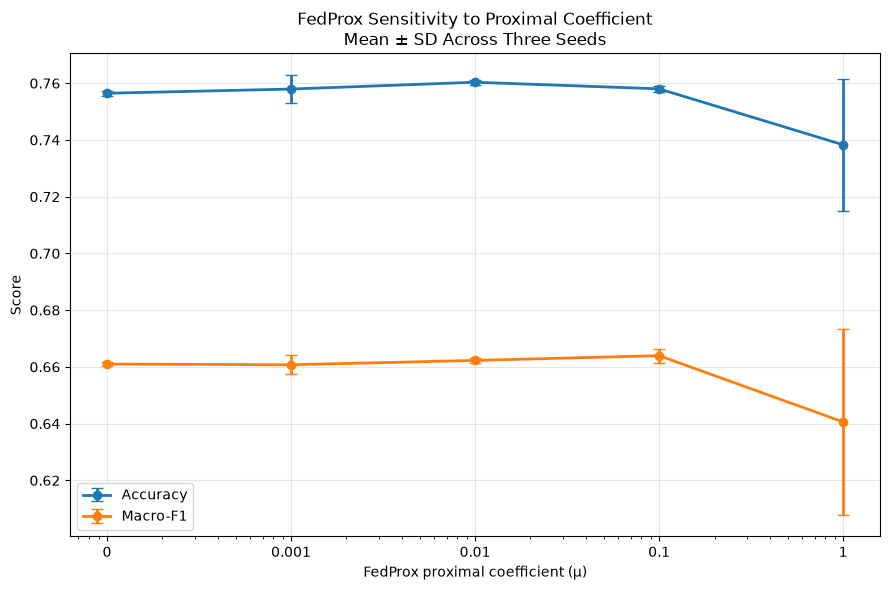

In [251]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
plot_df = mu_global_summary.copy()

# Small positive x-position for μ=0 so it can appear on a log axis
plot_df["mu_plot"] = plot_df["mu"].replace(0, 0.0001)

fig, ax = plt.subplots(figsize=(9, 6))

# Accuracy
ax.errorbar(
    plot_df["mu_plot"],
    plot_df["mean_accuracy"],
    yerr=plot_df["std_accuracy"],
    marker="o",
    capsize=4,
    linewidth=2,
    label="Accuracy"
)

# Macro-F1
ax.errorbar(
    plot_df["mu_plot"],
    plot_df["mean_macro_f1"],
    yerr=plot_df["std_macro_f1"],
    marker="o",
    capsize=4,
    linewidth=2,
    label="Macro-F1"
)

ax.set_xscale("log")

# Show the actual μ values, including zero
ax.set_xticks(plot_df["mu_plot"])
ax.set_xticklabels(["0", "0.001", "0.01", "0.1", "1"])

ax.set_xlabel("FedProx proximal coefficient (μ)")
ax.set_ylabel("Score")
ax.set_title(
    "FedProx Sensitivity to Proximal Coefficient\n"
    "Mean ± SD Across Three Seeds"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [252]:
# Find variables in the notebook that may contain our completed FL results

candidate_names = [
    name for name in globals()
    if any(term in name.lower() for term in [
        "fedavg",
        "fedprox",
        "history",
        "run"
    ])
]

print("Possible relevant variables:")
for name in sorted(candidate_names):
    print(name)

Possible relevant variables:
FEDPROX_MU
FacilityDeliveryFedProxClient
RegionalFedAvg
controlled_fedavg_initial_model
create_fedprox_client
fedavg
fedavg_controlled_model
fedavg_controlled_results
fedavg_controlled_results_df
fedavg_controlled_strategy
fedavg_final
fedavg_global_model
fedavg_regional_df
fedavg_regional_metrics
fedavg_results
fedavg_results_df
fedavg_seed123
fedavg_seed2024
fedavg_seed42
fedavg_start_model
fedavg_state
fedavg_summary
fedavg_weight
fedprox_controlled_strategy
fedprox_final
fedprox_heterogeneity_summary
fedprox_model
fedprox_mu_runs
fedprox_regional_df
fedprox_regional_metrics
fedprox_results
fedprox_results_df
fedprox_seed123
fedprox_seed2024
fedprox_seed42
fedprox_start_model
fedprox_strategy
fedprox_summary
final_runs
history
history_fedavg_controlled
history_fedavg_flower
history_fedprox_controlled
history_fedprox_flower
make_fedprox_client_fn
repro_fedavg_model
repro_fedavg_model_v2
repro_fedavg_results
repro_fedavg_results_v2
repro_fedprox_model
repr

In [253]:
# Inspect the six final experiment result objects

for name in [
    "fedavg_seed42",
    "fedavg_seed123",
    "fedavg_seed2024",
    "fedprox_seed42",
    "fedprox_seed123",
    "fedprox_seed2024"
]:
    obj = globals()[name]

    print(f"\n{name}")
    print("Type:", type(obj))

    if isinstance(obj, dict):
        print("Keys:", obj.keys())
    else:
        print("Value:", obj)


fedavg_seed42
Type: <class 'dict'>
Keys: dict_keys(['algorithm', 'seed', 'history', 'regional_metrics'])

fedavg_seed123
Type: <class 'dict'>
Keys: dict_keys(['algorithm', 'seed', 'history', 'regional_metrics'])

fedavg_seed2024
Type: <class 'dict'>
Keys: dict_keys(['algorithm', 'seed', 'history', 'regional_metrics'])

fedprox_seed42
Type: <class 'dict'>
Keys: dict_keys(['algorithm', 'seed', 'history', 'regional_metrics'])

fedprox_seed123
Type: <class 'dict'>
Keys: dict_keys(['algorithm', 'seed', 'history', 'regional_metrics'])

fedprox_seed2024
Type: <class 'dict'>
Keys: dict_keys(['algorithm', 'seed', 'history', 'regional_metrics'])


In [254]:
# Extract 10-round global metrics from the completed FedAvg and FedProx runs

final_experiment_runs = {
    "FedAvg": [
        fedavg_seed42,
        fedavg_seed123,
        fedavg_seed2024
    ],
    "FedProx": [
        fedprox_seed42,
        fedprox_seed123,
        fedprox_seed2024
    ]
}

learning_curve_rows = []

for algorithm, runs in final_experiment_runs.items():

    for run in runs:

        seed = run["seed"]
        history = run["history"]

        accuracy_history = dict(history.metrics_distributed["accuracy"])
        macro_f1_history = dict(history.metrics_distributed["macro_f1"])

        for round_number in accuracy_history:

            learning_curve_rows.append({
                "algorithm": algorithm,
                "seed": seed,
                "round": round_number,
                "accuracy": accuracy_history[round_number],
                "macro_f1": macro_f1_history[round_number]
            })

learning_curve_df = pd.DataFrame(learning_curve_rows)

display(learning_curve_df)

,algorithm,seed,round,accuracy,macro_f1
0,FedAvg,42,1,0.529247,0.437500
1,FedAvg,42,2,0.663482,0.551768
2,FedAvg,42,3,0.731531,0.639097
3,FedAvg,42,4,0.747145,0.655337
4,FedAvg,42,5,0.753204,0.660638
5,FedAvg,42,6,0.752971,0.659935
6,FedAvg,42,7,0.756467,0.664033
7,FedAvg,42,8,0.757865,0.663437
8,FedAvg,42,9,0.759031,0.663971
9,FedAvg,42,10,0.756700,0.661618


In [255]:
# Mean and standard deviation across the three seeds for each round

learning_curve_summary = (
    learning_curve_df
    .groupby(["algorithm", "round"])
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std")
    )
    .reset_index()
)

display(learning_curve_summary)

,algorithm,round,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1
0,FedAvg,1,0.588829,0.064561,0.431768,0.079709
1,FedAvg,2,0.664336,0.084715,0.518298,0.154461
2,FedAvg,3,0.718403,0.044926,0.617722,0.062109
3,FedAvg,4,0.747223,0.010371,0.653988,0.012647
4,FedAvg,5,0.754137,0.002911,0.661027,0.004233
5,FedAvg,6,0.755690,0.003746,0.662413,0.004194
6,FedAvg,7,0.757011,0.002951,0.663451,0.004211
7,FedAvg,8,0.756933,0.000932,0.661833,0.001423
8,FedAvg,9,0.757399,0.001759,0.661672,0.002210
9,FedAvg,10,0.756855,0.000942,0.660908,0.000702


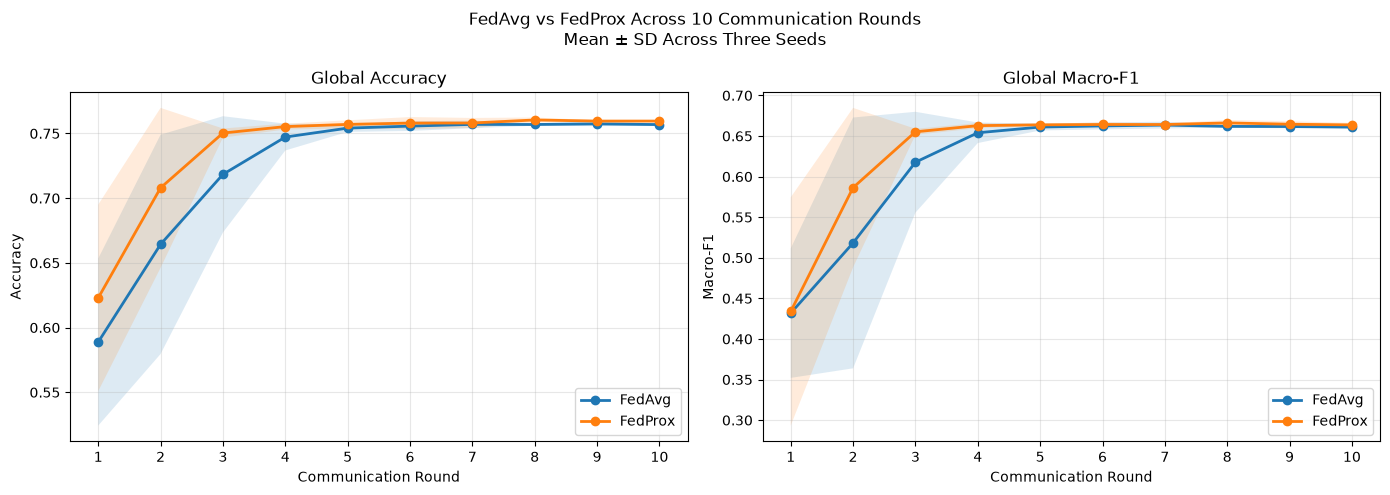

In [256]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for algorithm in ["FedAvg", "FedProx"]:

    data = learning_curve_summary[
        learning_curve_summary["algorithm"] == algorithm
    ]

    rounds = data["round"]

    # Accuracy
    axes[0].plot(
        rounds,
        data["mean_accuracy"],
        marker="o",
        linewidth=2,
        label=algorithm
    )

    axes[0].fill_between(
        rounds,
        data["mean_accuracy"] - data["std_accuracy"],
        data["mean_accuracy"] + data["std_accuracy"],
        alpha=0.15
    )

    # Macro-F1
    axes[1].plot(
        rounds,
        data["mean_macro_f1"],
        marker="o",
        linewidth=2,
        label=algorithm
    )

    axes[1].fill_between(
        rounds,
        data["mean_macro_f1"] - data["std_macro_f1"],
        data["mean_macro_f1"] + data["std_macro_f1"],
        alpha=0.15
    )


# Accuracy panel
axes[0].set_title("Global Accuracy")
axes[0].set_xlabel("Communication Round")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(range(1, 11))
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Macro-F1 panel
axes[1].set_title("Global Macro-F1")
axes[1].set_xlabel("Communication Round")
axes[1].set_ylabel("Macro-F1")
axes[1].set_xticks(range(1, 11))
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle(
    "FedAvg vs FedProx Across 10 Communication Rounds\n"
    "Mean ± SD Across Three Seeds"
)

plt.tight_layout()
plt.show()

In [257]:
print("FedAvg regional:")
print(fedavg_regional_df.columns.tolist())
display(fedavg_regional_df.head())

print("\nFedProx regional:")
print(fedprox_regional_df.columns.tolist())
display(fedprox_regional_df.head())

FedAvg regional:
['algorithm', 'round', 'region_id', 'region', 'accuracy', 'precision', 'recall', 'f1', 'macro_f1']


,algorithm,round,region_id,region,accuracy,precision,recall,f1,macro_f1
0,FedAvg,1,3,South East,0.235043,0.954545,0.055556,0.105000,0.218545
1,FedAvg,1,0,North Central,0.514323,0.909091,0.075000,0.138568,0.400200
2,FedAvg,1,1,North East,0.745556,0.692308,0.038462,0.072874,0.462709
3,FedAvg,1,4,South South,0.541463,0.875000,0.070000,0.129630,0.409186
4,FedAvg,1,5,South West,0.219462,0.863636,0.048346,0.091566,0.203678



FedProx regional:
['algorithm', 'round', 'region_id', 'region', 'accuracy', 'precision', 'recall', 'f1', 'macro_f1']


,algorithm,round,region_id,region,accuracy,precision,recall,f1,macro_f1
0,FedProx,1,5,South West,0.194617,0.833333,0.012723,0.025063,0.169498
1,FedProx,1,0,North Central,0.480469,1.000000,0.002500,0.004988,0.326723
2,FedProx,1,2,North West,0.843106,0.000000,0.000000,0.000000,0.457438
3,FedProx,1,1,North East,0.740000,0.500000,0.004274,0.008475,0.429429
4,FedProx,1,3,South East,0.194444,0.571429,0.010582,0.020779,0.168284


In [258]:
# Extract final-round regional results from all six completed experiments

regional_final_rows = []

final_runs = {
    "FedAvg": [
        fedavg_seed42,
        fedavg_seed123,
        fedavg_seed2024
    ],
    "FedProx": [
        fedprox_seed42,
        fedprox_seed123,
        fedprox_seed2024
    ]
}

for algorithm, runs in final_runs.items():

    for run in runs:

        seed = run["seed"]
        regional_metrics = run["regional_metrics"]

        # Final communication round
        final_round = max(regional_metrics.keys())

        for metrics in regional_metrics[final_round]:

            region_id = int(metrics["region_id"])
            region = list(region_names.values())[region_id]

            regional_final_rows.append({
                "algorithm": algorithm,
                "seed": seed,
                "region_id": region_id,
                "region": region,
                "accuracy": metrics["accuracy"],
                "macro_f1": metrics["macro_f1"]
            })

regional_final_df = pd.DataFrame(regional_final_rows)

display(
    regional_final_df.sort_values(
        ["algorithm", "region_id", "seed"]
    )
)

,algorithm,seed,region_id,region,accuracy,macro_f1
3,FedAvg,42,0,North Central,0.661458,0.660627
7,FedAvg,123,0,North Central,0.660156,0.660087
13,FedAvg,2024,0,North Central,0.654948,0.653863
5,FedAvg,42,1,North East,0.767778,0.652078
10,FedAvg,123,1,North East,0.771111,0.670104
12,FedAvg,2024,1,North East,0.764444,0.643647
0,FedAvg,42,2,North West,0.855784,0.719296
8,FedAvg,123,2,North West,0.847068,0.713897
17,FedAvg,2024,2,North West,0.858954,0.723078
1,FedAvg,42,3,South East,0.784188,0.667817


In [259]:
# Regional final-round performance across the three seeds

regional_final_summary = (
    regional_final_df
    .groupby(["algorithm", "region_id", "region"])
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std")
    )
    .reset_index()
)

display(
    regional_final_summary.sort_values(
        ["region_id", "algorithm"]
    )
)

,algorithm,region_id,region,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1
0,FedAvg,0,North Central,0.658854,0.003445,0.658192,0.003759
6,FedProx,0,North Central,0.663194,0.009773,0.662015,0.010419
1,FedAvg,1,North East,0.767778,0.003333,0.655277,0.013516
7,FedProx,1,North East,0.768148,0.003572,0.649103,0.010713
2,FedAvg,2,North West,0.853936,0.006155,0.718757,0.004614
8,FedProx,2,North West,0.857898,0.002547,0.721409,0.004757
3,FedAvg,3,South East,0.797009,0.011897,0.673538,0.016404
9,FedProx,3,South East,0.801994,0.013570,0.692391,0.007927
4,FedAvg,4,South South,0.607317,0.011177,0.576753,0.016195
10,FedProx,4,South South,0.607317,0.006453,0.578603,0.007619


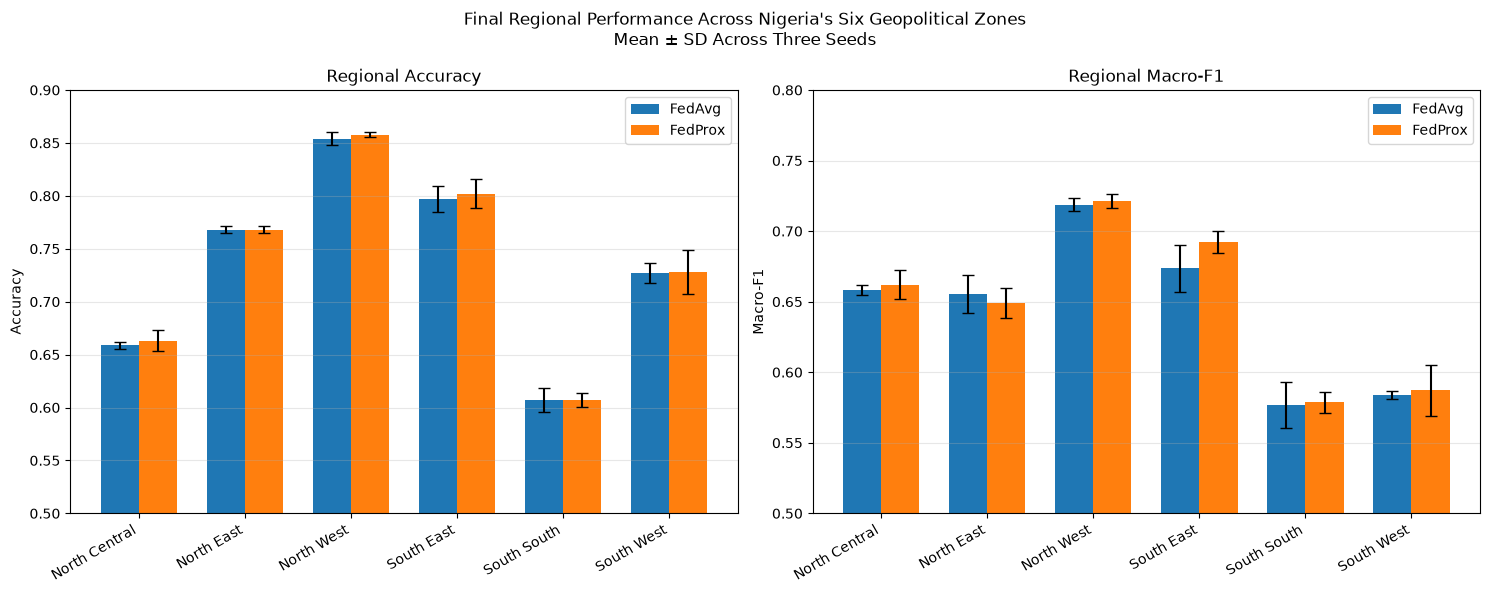

In [260]:
import matplotlib.pyplot as plt
import numpy as np

# Desired geographic order
region_order = [
    "North Central",
    "North East",
    "North West",
    "South East",
    "South South",
    "South West"
]

plot_df = regional_final_summary.copy()

# Put regions in the desired order
plot_df["region"] = pd.Categorical(
    plot_df["region"],
    categories=region_order,
    ordered=True
)

plot_df = plot_df.sort_values(["region", "algorithm"])

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(region_order))
width = 0.36

fedavg = plot_df[plot_df["algorithm"] == "FedAvg"].set_index("region").loc[region_order]
fedprox = plot_df[plot_df["algorithm"] == "FedProx"].set_index("region").loc[region_order]

# -------------------------
# Accuracy
# -------------------------

axes[0].bar(
    x - width/2,
    fedavg["mean_accuracy"],
    width,
    yerr=fedavg["std_accuracy"],
    capsize=4,
    label="FedAvg"
)

axes[0].bar(
    x + width/2,
    fedprox["mean_accuracy"],
    width,
    yerr=fedprox["std_accuracy"],
    capsize=4,
    label="FedProx"
)

axes[0].set_title("Regional Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    region_order,
    rotation=30,
    ha="right"
)
axes[0].set_ylim(0.5, 0.9)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

# -------------------------
# Macro-F1
# -------------------------

axes[1].bar(
    x - width/2,
    fedavg["mean_macro_f1"],
    width,
    yerr=fedavg["std_macro_f1"],
    capsize=4,
    label="FedAvg"
)

axes[1].bar(
    x + width/2,
    fedprox["mean_macro_f1"],
    width,
    yerr=fedprox["std_macro_f1"],
    capsize=4,
    label="FedProx"
)

axes[1].set_title("Regional Macro-F1")
axes[1].set_ylabel("Macro-F1")
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    region_order,
    rotation=30,
    ha="right"
)
axes[1].set_ylim(0.5, 0.8)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

fig.suptitle(
    "Final Regional Performance Across Nigeria's Six Geopolitical Zones\n"
    "Mean ± SD Across Three Seeds"
)

plt.tight_layout()
plt.show()

In [261]:
# Quantify final regional performance heterogeneity

regional_gap_summary = (
    regional_final_summary
    .groupby("algorithm")
    .agg(
        mean_regional_accuracy=("mean_accuracy", "mean"),
        regional_accuracy_sd=("mean_accuracy", "std"),
        min_regional_accuracy=("mean_accuracy", "min"),
        max_regional_accuracy=("mean_accuracy", "max"),
        mean_regional_macro_f1=("mean_macro_f1", "mean"),
        regional_macro_f1_sd=("mean_macro_f1", "std"),
        min_regional_macro_f1=("mean_macro_f1", "min"),
        max_regional_macro_f1=("mean_macro_f1", "max")
    )
    .reset_index()
)

regional_gap_summary["accuracy_gap"] = (
    regional_gap_summary["max_regional_accuracy"]
    - regional_gap_summary["min_regional_accuracy"]
)

regional_gap_summary["macro_f1_gap"] = (
    regional_gap_summary["max_regional_macro_f1"]
    - regional_gap_summary["min_regional_macro_f1"]
)

display(regional_gap_summary)

,algorithm,mean_regional_accuracy,regional_accuracy_sd,min_regional_accuracy,max_regional_accuracy,mean_regional_macro_f1,regional_macro_f1_sd,min_regional_macro_f1,max_regional_macro_f1,accuracy_gap,macro_f1_gap
0,FedAvg,0.735267,0.090813,0.607317,0.853936,0.644380,0.054661,0.576753,0.718757,0.246618,0.142004
1,FedProx,0.737773,0.091817,0.607317,0.857898,0.648455,0.056687,0.578603,0.721409,0.250580,0.142806


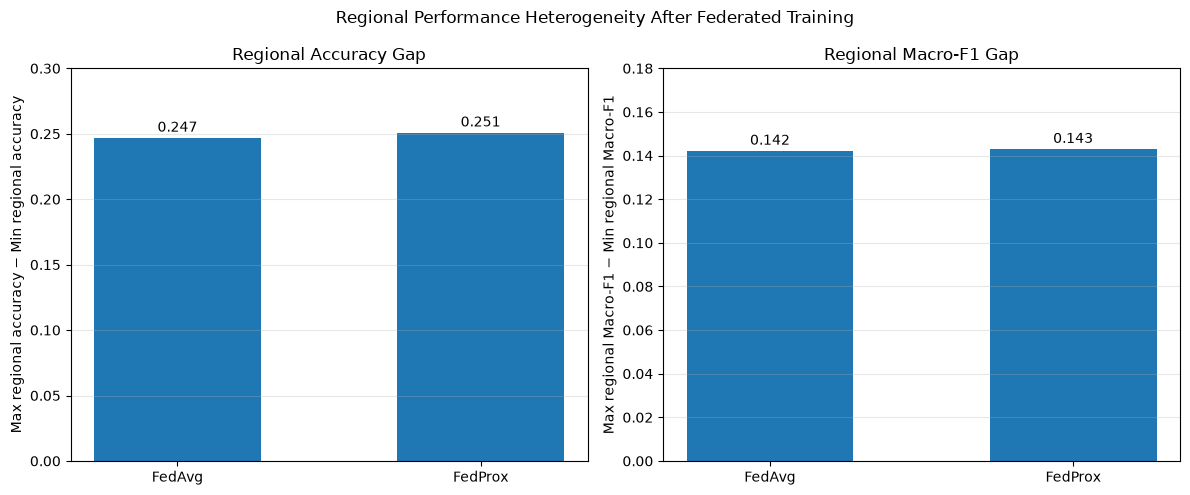

In [262]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
gap_plot = regional_gap_summary.copy()

x = np.arange(len(gap_plot))
width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# Accuracy gap
# -------------------------

axes[0].bar(
    x,
    gap_plot["accuracy_gap"],
    width=0.55
)

axes[0].set_title("Regional Accuracy Gap")
axes[0].set_ylabel("Max regional accuracy − Min regional accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(gap_plot["algorithm"])
axes[0].set_ylim(0, 0.30)
axes[0].grid(axis="y", alpha=0.3)

# Add values above bars
for i, value in enumerate(gap_plot["accuracy_gap"]):
    axes[0].text(
        i,
        value + 0.005,
        f"{value:.3f}",
        ha="center"
    )

# -------------------------
# Macro-F1 gap
# -------------------------

axes[1].bar(
    x,
    gap_plot["macro_f1_gap"],
    width=0.55
)

axes[1].set_title("Regional Macro-F1 Gap")
axes[1].set_ylabel("Max regional Macro-F1 − Min regional Macro-F1")
axes[1].set_xticks(x)
axes[1].set_xticklabels(gap_plot["algorithm"])
axes[1].set_ylim(0, 0.18)
axes[1].grid(axis="y", alpha=0.3)

for i, value in enumerate(gap_plot["macro_f1_gap"]):
    axes[1].text(
        i,
        value + 0.003,
        f"{value:.3f}",
        ha="center"
    )

fig.suptitle(
    "Regional Performance Heterogeneity After Federated Training"
)

plt.tight_layout()
plt.show()

Results will be saved to: C:\Users\usher\flow-fellowship-lab\research_results


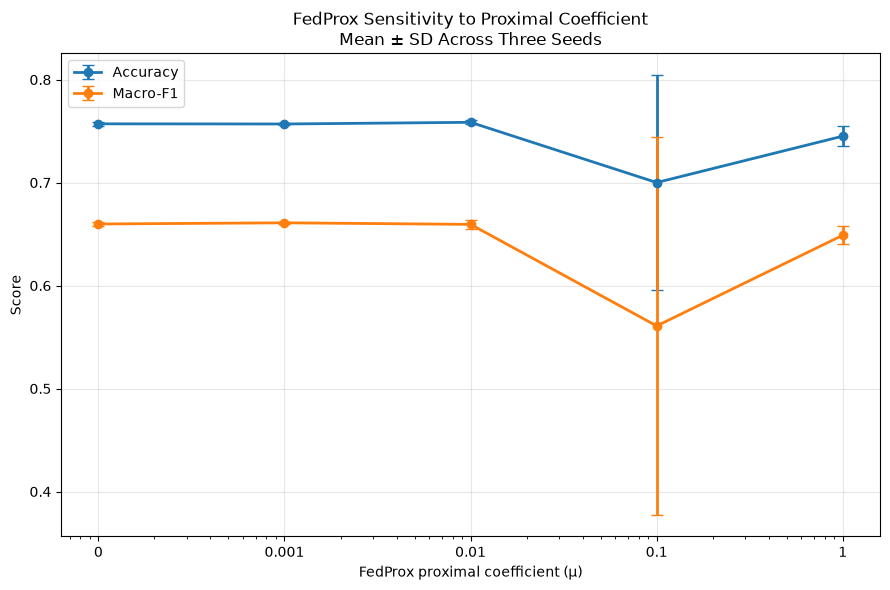

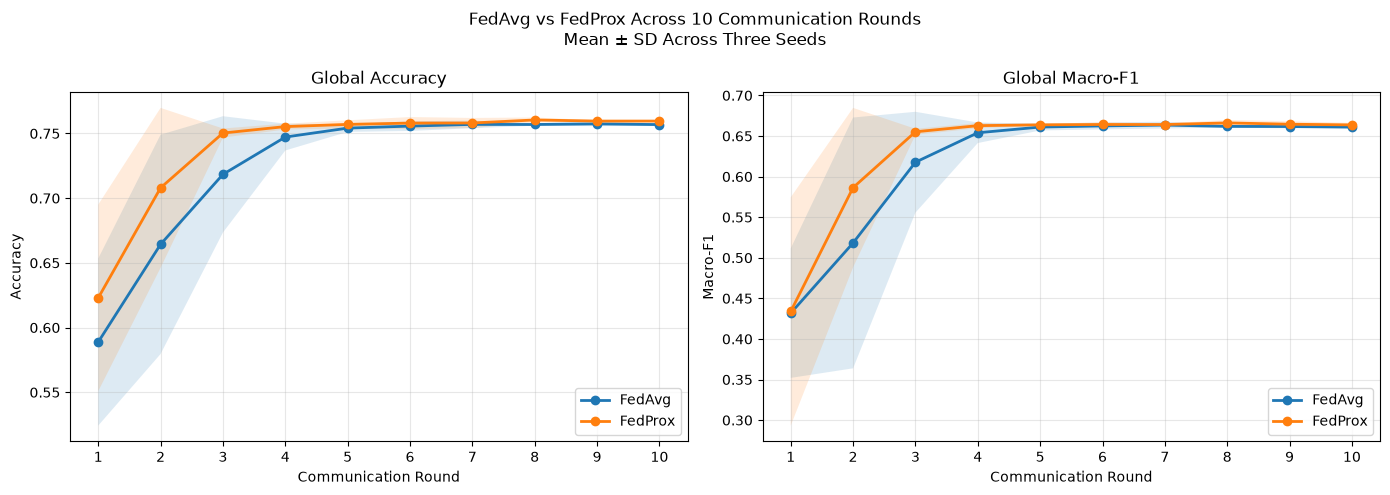

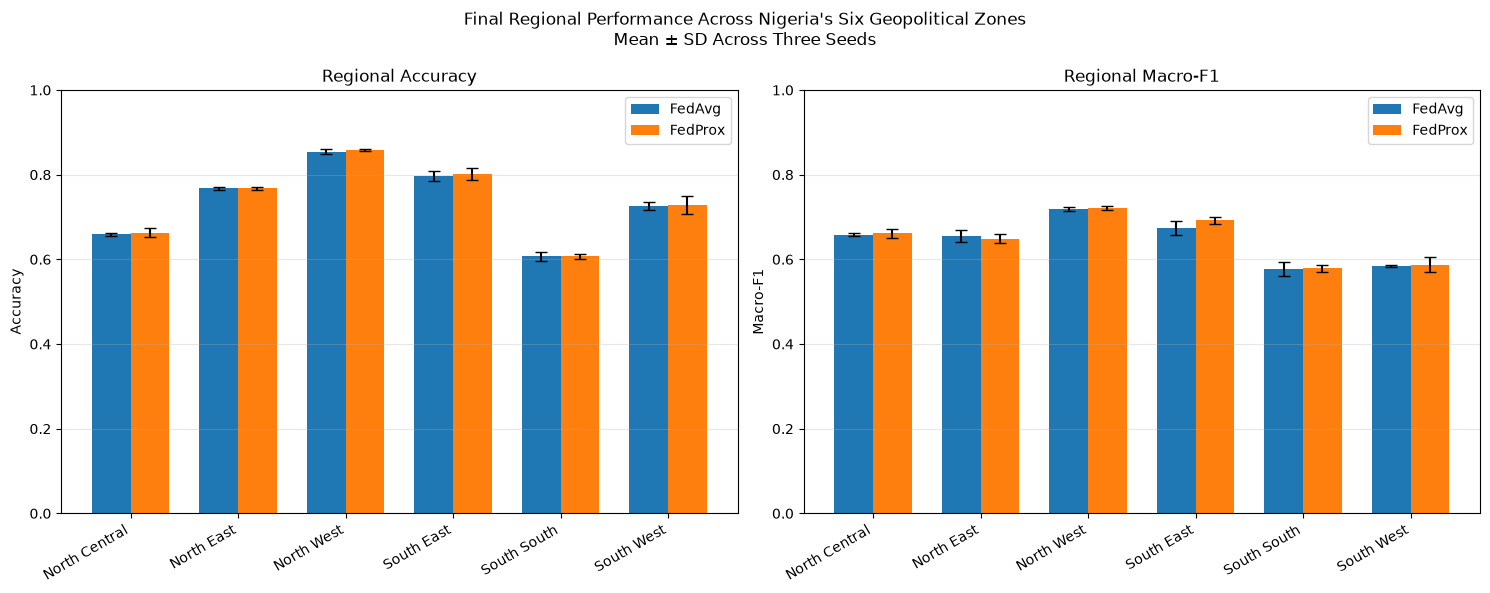

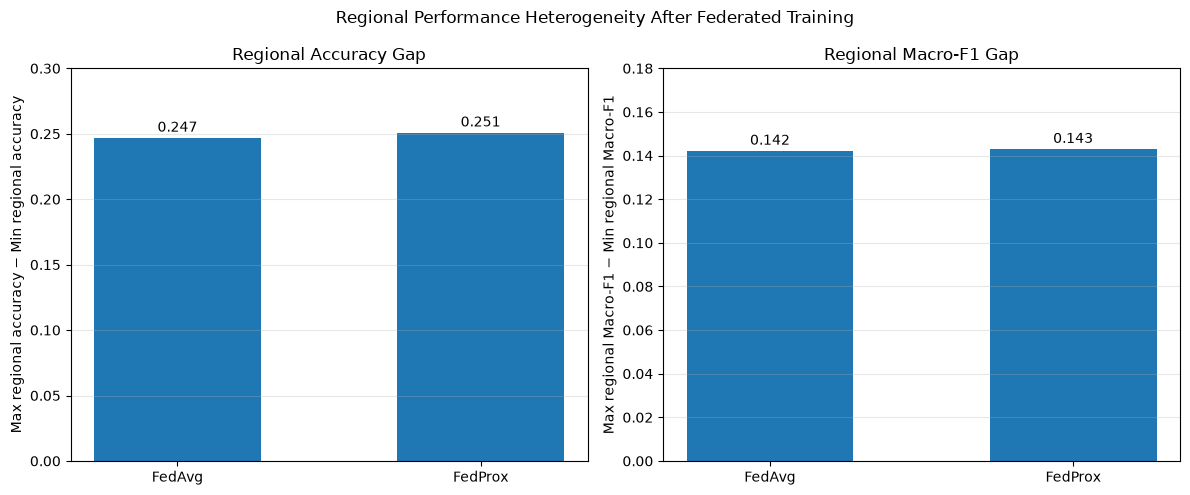


FINAL RESULTS PACKAGE CREATED
fedprox_mu_sensitivity.csv
fedprox_mu_sensitivity_summary.csv
fig1_fedprox_mu_sensitivity.png
fig2_fedavg_vs_fedprox_learning_curves.png
fig3_regional_performance.png
fig4_regional_heterogeneity.png
global_learning_curves.csv
global_learning_curves_summary.csv
regional_final_performance.csv
regional_final_performance_summary.csv
regional_heterogeneity_gaps.csv

Location:
C:\Users\usher\flow-fellowship-lab\research_results


In [263]:
# ============================================================
# FINAL RESEARCH RESULTS PACKAGE
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create results directory beside the notebook
results_dir = Path("research_results")
results_dir.mkdir(exist_ok=True)

print(f"Results will be saved to: {results_dir.resolve()}")


# ============================================================
# 1. FINAL EXPERIMENT OBJECTS
# ============================================================

final_runs = {
    "FedAvg": {
        42: fedavg_seed42,
        123: fedavg_seed123,
        2024: fedavg_seed2024
    },
    "FedProx": {
        42: fedprox_seed42,
        123: fedprox_seed123,
        2024: fedprox_seed2024
    }
}


# ============================================================
# 2. GLOBAL LEARNING CURVES
# ============================================================

learning_curve_rows = []

for algorithm, seed_runs in final_runs.items():

    for seed, result in seed_runs.items():

        history = result["history"]

        accuracy_history = dict(
            history.metrics_distributed["accuracy"]
        )

        macro_f1_history = dict(
            history.metrics_distributed["macro_f1"]
        )

        for round_number in accuracy_history:

            learning_curve_rows.append({
                "algorithm": algorithm,
                "seed": seed,
                "round": round_number,
                "accuracy": accuracy_history[round_number],
                "macro_f1": macro_f1_history[round_number]
            })


learning_curve_df = pd.DataFrame(learning_curve_rows)

learning_curve_summary = (
    learning_curve_df
    .groupby(["algorithm", "round"])
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std")
    )
    .reset_index()
)

learning_curve_df.to_csv(
    results_dir / "global_learning_curves.csv",
    index=False
)

learning_curve_summary.to_csv(
    results_dir / "global_learning_curves_summary.csv",
    index=False
)


# ============================================================
# 3. FINAL REGIONAL PERFORMANCE
# ============================================================

regional_final_rows = []

for algorithm, seed_runs in final_runs.items():

    for seed, result in seed_runs.items():

        regional_metrics = result["regional_metrics"]

        final_round = max(regional_metrics.keys())

        for metrics in regional_metrics[final_round]:

            region_id = int(metrics["region_id"])
            region = list(region_names.values())[region_id]

            regional_final_rows.append({
                "algorithm": algorithm,
                "seed": seed,
                "region_id": region_id,
                "region": region,
                "accuracy": metrics["accuracy"],
                "macro_f1": metrics["macro_f1"]
            })


regional_final_df = pd.DataFrame(regional_final_rows)

regional_final_summary = (
    regional_final_df
    .groupby(["algorithm", "region_id", "region"])
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std")
    )
    .reset_index()
)

regional_final_df.to_csv(
    results_dir / "regional_final_performance.csv",
    index=False
)

regional_final_summary.to_csv(
    results_dir / "regional_final_performance_summary.csv",
    index=False
)


# ============================================================
# 4. REGIONAL HETEROGENEITY GAPS
# ============================================================

regional_gap_summary = (
    regional_final_summary
    .groupby("algorithm")
    .agg(
        mean_regional_accuracy=("mean_accuracy", "mean"),
        regional_accuracy_sd=("mean_accuracy", "std"),
        min_regional_accuracy=("mean_accuracy", "min"),
        max_regional_accuracy=("mean_accuracy", "max"),
        mean_regional_macro_f1=("mean_macro_f1", "mean"),
        regional_macro_f1_sd=("mean_macro_f1", "std"),
        min_regional_macro_f1=("mean_macro_f1", "min"),
        max_regional_macro_f1=("mean_macro_f1", "max")
    )
    .reset_index()
)

regional_gap_summary["accuracy_gap"] = (
    regional_gap_summary["max_regional_accuracy"]
    - regional_gap_summary["min_regional_accuracy"]
)

regional_gap_summary["macro_f1_gap"] = (
    regional_gap_summary["max_regional_macro_f1"]
    - regional_gap_summary["min_regional_macro_f1"]
)

regional_gap_summary.to_csv(
    results_dir / "regional_heterogeneity_gaps.csv",
    index=False
)


# ============================================================
# 5. FEDPROX μ-SENSITIVITY RESULTS
# ============================================================

# These are the completed 15 runs from the μ-sensitivity experiment.
# The raw fedprox_mu_runs object is no longer in memory after the
# notebook rerun, so we preserve the already-extracted results.

mu_results_df = pd.DataFrame([
    [0.000, 42,   0.515009, 0.757166, 0.662914, 0.584570, 0.611001, 0.658819],
    [0.000, 123,  0.504250, 0.758797, 0.644376, 0.611550, 0.619092, 0.661977],
    [0.000, 2024, 0.512872, 0.755302, 0.657066, 0.585395, 0.609885, 0.658679],

    [0.001, 42,   0.515255, 0.756467, 0.651957, 0.595901, 0.613428, 0.660866],
    [0.001, 123,  0.512648, 0.757865, 0.653208, 0.605986, 0.619700, 0.661683],
    [0.001, 2024, 0.506012, 0.756467, 0.670922, 0.574389, 0.607159, 0.660343],

    [0.010, 42,   0.518239, 0.756467, 0.645495, 0.610628, 0.617647, 0.654425],
    [0.010, 123,  0.509486, 0.759497, 0.661025, 0.590332, 0.612519, 0.660360],
    [0.010, 2024, 0.506818, 0.759730, 0.654863, 0.602365, 0.618547, 0.663556],

    [0.100, 42,   0.506526, 0.760662, 0.667957, 0.596076, 0.620901, 0.667971],
    [0.100, 123,  0.508700, 0.759730, 0.663286, 0.594531, 0.616898, 0.665238],
    [0.100, 2024, 0.589720, 0.579818, 0.000000, 0.000000, 0.000000, 0.349348],

    [1.000, 42,   0.553563, 0.755302, 0.681625, 0.564296, 0.606509, 0.658468],
    [1.000, 123,  0.582243, 0.743883, 0.683352, 0.499820, 0.566035, 0.646080],
    [1.000, 2024, 0.563429, 0.736192, 0.664675, 0.508852, 0.564064, 0.642271]
], columns=[
    "mu",
    "seed",
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "macro_f1"
])

mu_global_summary = (
    mu_results_df
    .groupby("mu")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
        mean_loss=("loss", "mean"),
        std_loss=("loss", "std")
    )
    .reset_index()
)

mu_results_df.to_csv(
    results_dir / "fedprox_mu_sensitivity.csv",
    index=False
)

mu_global_summary.to_csv(
    results_dir / "fedprox_mu_sensitivity_summary.csv",
    index=False
)


# ============================================================
# 6. FIGURE 1 — μ SENSITIVITY
# ============================================================

plot_df = mu_global_summary.copy()
plot_df["mu_plot"] = plot_df["mu"].replace(0, 0.0001)

fig, ax = plt.subplots(figsize=(9, 6))

ax.errorbar(
    plot_df["mu_plot"],
    plot_df["mean_accuracy"],
    yerr=plot_df["std_accuracy"],
    marker="o",
    capsize=4,
    linewidth=2,
    label="Accuracy"
)

ax.errorbar(
    plot_df["mu_plot"],
    plot_df["mean_macro_f1"],
    yerr=plot_df["std_macro_f1"],
    marker="o",
    capsize=4,
    linewidth=2,
    label="Macro-F1"
)

ax.set_xscale("log")
ax.set_xticks(plot_df["mu_plot"])
ax.set_xticklabels(["0", "0.001", "0.01", "0.1", "1"])

ax.set_xlabel("FedProx proximal coefficient (μ)")
ax.set_ylabel("Score")
ax.set_title(
    "FedProx Sensitivity to Proximal Coefficient\n"
    "Mean ± SD Across Three Seeds"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

fig.savefig(
    results_dir / "fig1_fedprox_mu_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# 7. FIGURE 2 — FEDAVG VS FEDPROX LEARNING CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for algorithm in ["FedAvg", "FedProx"]:

    data = learning_curve_summary[
        learning_curve_summary["algorithm"] == algorithm
    ]

    rounds = data["round"]

    axes[0].plot(
        rounds,
        data["mean_accuracy"],
        marker="o",
        linewidth=2,
        label=algorithm
    )

    axes[0].fill_between(
        rounds,
        data["mean_accuracy"] - data["std_accuracy"],
        data["mean_accuracy"] + data["std_accuracy"],
        alpha=0.15
    )

    axes[1].plot(
        rounds,
        data["mean_macro_f1"],
        marker="o",
        linewidth=2,
        label=algorithm
    )

    axes[1].fill_between(
        rounds,
        data["mean_macro_f1"] - data["std_macro_f1"],
        data["mean_macro_f1"] + data["std_macro_f1"],
        alpha=0.15
    )

axes[0].set_title("Global Accuracy")
axes[0].set_xlabel("Communication Round")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(range(1, 11))
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Global Macro-F1")
axes[1].set_xlabel("Communication Round")
axes[1].set_ylabel("Macro-F1")
axes[1].set_xticks(range(1, 11))
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle(
    "FedAvg vs FedProx Across 10 Communication Rounds\n"
    "Mean ± SD Across Three Seeds"
)

plt.tight_layout()

fig.savefig(
    results_dir / "fig2_fedavg_vs_fedprox_learning_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# 8. FIGURE 3 — REGIONAL PERFORMANCE
# ============================================================

region_order = [
    "North Central",
    "North East",
    "North West",
    "South East",
    "South South",
    "South West"
]

plot_df = regional_final_summary.copy()

plot_df["region"] = pd.Categorical(
    plot_df["region"],
    categories=region_order,
    ordered=True
)

plot_df = plot_df.sort_values(["region", "algorithm"])

x = np.arange(len(region_order))
width = 0.36

fedavg = (
    plot_df[plot_df["algorithm"] == "FedAvg"]
    .set_index("region")
    .loc[region_order]
)

fedprox = (
    plot_df[plot_df["algorithm"] == "FedProx"]
    .set_index("region")
    .loc[region_order]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(
    x - width/2,
    fedavg["mean_accuracy"],
    width,
    yerr=fedavg["std_accuracy"],
    capsize=4,
    label="FedAvg"
)

axes[0].bar(
    x + width/2,
    fedprox["mean_accuracy"],
    width,
    yerr=fedprox["std_accuracy"],
    capsize=4,
    label="FedProx"
)

axes[0].set_title("Regional Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    region_order,
    rotation=30,
    ha="right"
)
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].bar(
    x - width/2,
    fedavg["mean_macro_f1"],
    width,
    yerr=fedavg["std_macro_f1"],
    capsize=4,
    label="FedAvg"
)

axes[1].bar(
    x + width/2,
    fedprox["mean_macro_f1"],
    width,
    yerr=fedprox["std_macro_f1"],
    capsize=4,
    label="FedProx"
)

axes[1].set_title("Regional Macro-F1")
axes[1].set_ylabel("Macro-F1")
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    region_order,
    rotation=30,
    ha="right"
)
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

fig.suptitle(
    "Final Regional Performance Across Nigeria's Six Geopolitical Zones\n"
    "Mean ± SD Across Three Seeds"
)

plt.tight_layout()

fig.savefig(
    results_dir / "fig3_regional_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# 9. FIGURE 4 — REGIONAL HETEROGENEITY
# ============================================================

gap_plot = regional_gap_summary.copy()

x = np.arange(len(gap_plot))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    x,
    gap_plot["accuracy_gap"],
    width=0.55
)

axes[0].set_title("Regional Accuracy Gap")
axes[0].set_ylabel(
    "Max regional accuracy − Min regional accuracy"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(gap_plot["algorithm"])
axes[0].set_ylim(0, 0.30)
axes[0].grid(axis="y", alpha=0.3)

for i, value in enumerate(gap_plot["accuracy_gap"]):
    axes[0].text(
        i,
        value + 0.005,
        f"{value:.3f}",
        ha="center"
    )

axes[1].bar(
    x,
    gap_plot["macro_f1_gap"],
    width=0.55
)

axes[1].set_title("Regional Macro-F1 Gap")
axes[1].set_ylabel(
    "Max regional Macro-F1 − Min regional Macro-F1"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(gap_plot["algorithm"])
axes[1].set_ylim(0, 0.18)
axes[1].grid(axis="y", alpha=0.3)

for i, value in enumerate(gap_plot["macro_f1_gap"]):
    axes[1].text(
        i,
        value + 0.003,
        f"{value:.3f}",
        ha="center"
    )

fig.suptitle(
    "Regional Performance Heterogeneity After Federated Training"
)

plt.tight_layout()

fig.savefig(
    results_dir / "fig4_regional_heterogeneity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# 10. FINAL CHECK
# ============================================================

print("\n" + "="*60)
print("FINAL RESULTS PACKAGE CREATED")
print("="*60)

for file in sorted(results_dir.iterdir()):
    print(file.name)

print("\nLocation:")
print(results_dir.resolve())